In [1]:
cd e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\git_project

e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\git_project


In [2]:
# Import Radiomic and Clinical files

#-drop nHOC radiomic features
#-merge clinical and radiomic files

from src.data.preprocessing import merger, harmoniser

radiomic_file = r"E:\Box\One Drive To Box Migration\Immunotherapy_avicenne\processed_master_radiomic_folder_nov\paris_ici_radiomic_features_25HU_nov.csv"
clinical_file = r"E:\Box\One Drive To Box Migration\Immunotherapy_avicenne\clinical_data\2024_Oct_22_Paris_ICI_radiomic_clinical.csv"

df_merge = merger(radiomic_file, clinical_file, "Scan name", "SID")

df_merge

,N voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,FOS_CV,...,Post_IMM_Rx,Post_Imm_RxType,DODth/DOLFU,OS_event,OS,ProgressionDate,TTP_event,TTP,PFS_event,PFS
ABR1,1484736,1484736,163044,0.109813,0.386022,2.590525,280.675446,0.057522,281,0.188494,...,NaN,NaN,30/03/2023,1,14.30,NaN,0,14.301370,1,14.300000
ABR2,1528818,1528818,144962,0.094820,0.442725,2.258740,312.568160,0.086776,269,0.205887,...,NaN,NaN,25/10/2023,1,9.93,NaN,1,7.397260,1,7.397260
ABR3,1611153,1611153,169780,0.105378,0.391461,2.554531,296.463225,0.059988,248,0.527459,...,NaN,NaN,21/08/2023,1,15.29,NaN,0,15.287671,1,15.290000
ABR4,1476957,1476957,133962,0.090701,0.468182,2.135923,318.276935,0.102623,236,0.200488,...,NaN,NaN,16/10/2023,0,12.33,NaN,1,6.575342,1,6.575342
ABR5,1569267,1569267,162678,0.103665,0.401439,2.491037,297.100026,0.064693,260,0.232744,...,NaN,NaN,05/11/2021,0,0.99,NaN,0,0.986301,0,0.986301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ICL75,1844705,1844705,195650,0.106060,0.371782,2.689745,308.815261,0.051389,313,0.217589,...,NaN,NaN,10/10/2024,0,0.70,20/09/2024,0,0.000000,0,0.000000
ICL76,1383314,1383314,141196,0.102071,0.425215,2.351750,287.826586,0.076882,245,0.231905,...,NaN,NaN,08/10/2024,0,3.60,28/08/2024,0,2.300000,0,2.300000
ICL77,1771848,1771848,158952,0.089710,0.445488,2.244731,340.675469,0.088411,290,0.374063,...,NaN,NaN,14/10/2024,0,10.30,14/10/2024,0,10.300000,0,10.300000
ICL79,2375120,2375120,222260,0.093578,0.387329,2.581785,365.204747,0.058108,306,0.438178,...,NaN,NaN,18/10/2024,0,2.80,13/09/2024,0,1.600000,0,1.600000


C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge_pca["Manufacturer"][df_merge_pca["Manufacturer"] == "Siemens Healthineers"]="SIEMENS"
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:64: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = patches.Ellipse(mean, width, height, angle, edgecolor=color, facecolor='none', linewidth=1)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:64: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_harm_pca["Manufacturer"][df_harm_pca["Manufacturer"] == "Siemens Healthineers"]="SIEMENS"
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:126: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ellipse = patches.Ellipse(mean, width, height, angle, edgecolor=color, facecolor='none', linewidth=1)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3440855969.py:126: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases

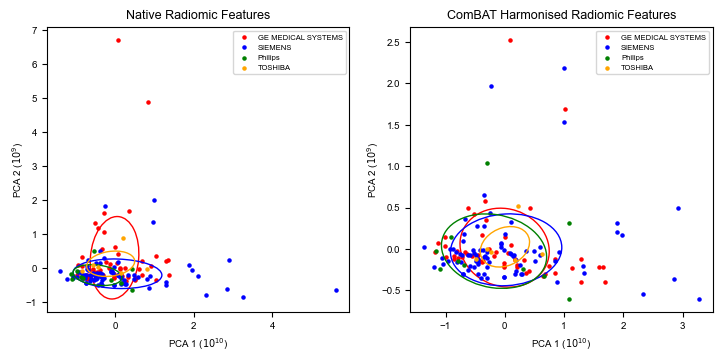

In [3]:
# Harmonise radiomic features and show PCA pre- and post- COMBAT harmonisation

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import ScalarFormatter
import numpy as np

mm_inch = 1/25.4

figure = plt.figure(figsize=(188*mm_inch, 0.5*188*mm_inch))

# Select radiomic features
radiomic_features = df_merge.columns[:892]

radiomic_features = radiomic_features.drop(["Centroid_x","Centroid_y","Centroid_z","maxVoxHotSpotCorr_x","maxVoxHotSpotCorr_y","maxVoxHotSpotCorr_z","LabelID","HOC","nHOC","MSR"])

df_merge_pca = df_merge.copy()
df_merge_pca["Manufacturer"][df_merge_pca["Manufacturer"] == "Siemens Healthineers"]="SIEMENS"

# # Scale features
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(df_merge[radiomic_features])

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_merge[radiomic_features])

# Add PCA components to the DataFrame
df_merge_pca["PCA_1"] = df_pca[:, 0]/1e10
df_merge_pca["PCA_2"] = df_pca[:, 1]/1e9

# Define colors for different manufacturers
colours = {
    'GE MEDICAL SYSTEMS': "red",
    'SIEMENS': "blue",
    'Philips': "green",
    'TOSHIBA': "orange",
}

# Map colors to the DataFrame
df_merge_pca["Centre_colour"] = df_merge_pca["Manufacturer"].map(colours)

# Plot PCA with different center colors
ax = figure.add_subplot(1, 2, 1)
for manufacturer, color in colours.items():
    subset = df_merge_pca[df_merge_pca["Manufacturer"] == manufacturer]
    plt.scatter(subset["PCA_1"], subset["PCA_2"], c=color, label=manufacturer, s=5)

    # Calculate the mean and covariance of the points
    mean = subset[["PCA_1", "PCA_2"]].mean().values
    cov = np.cov(subset[["PCA_1", "PCA_2"]].values.T)
    
    # Calculate the ellipse parameters
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues)  # 68% confidence interval

    # Draw the ellipse
    ellipse = patches.Ellipse(mean, width, height, angle, edgecolor=color, facecolor='none', linewidth=1)
    plt.gca().add_patch(ellipse)

plt.xlabel("PCA 1 ($10^{10}$)", fontsize=7, fontname="Arial")
plt.ylabel("PCA 2 ($10^9$)", fontsize=7, fontname="Arial", labelpad=0)
plt.xticks(fontsize=7, fontname='Arial')
plt.yticks(fontsize=7, fontname='Arial')
plt.title("Native Radiomic Features", fontsize=9, fontname='Arial')
plt.legend(loc='upper right', prop={'size': 5.5, 'family': 'Arial'})


# Select radiomic features
radiomic_features = df_merge.columns[:892]

radiomic_features = radiomic_features.drop(["Centroid_x","Centroid_y","Centroid_z","maxVoxHotSpotCorr_x","maxVoxHotSpotCorr_y","maxVoxHotSpotCorr_z","LabelID","HOC","nHOC","MSR"])

df_harm_pca = harmoniser(df_merge, radiomic_features, "Manufacturer", reference_batch="SIEMENS")

df_harm_pca["Manufacturer"][df_harm_pca["Manufacturer"] == "Siemens Healthineers"]="SIEMENS"


# # Scale features
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(df_merge[radiomic_features])

# Perform PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_harm_pca[radiomic_features])

# Add PCA components to the DataFrame
df_harm_pca["PCA_1"] = df_pca[:, 0]/1e10
df_harm_pca["PCA_2"] = df_pca[:, 1]/1e9

# Define colors for different manufacturers
colours = {
    'GE MEDICAL SYSTEMS': "red",
    'SIEMENS': "blue",
    'Philips': "green",
    'TOSHIBA': "orange",
}

# Map colors to the DataFrame
df_harm_pca["Centre_colour"] = df_harm_pca["Manufacturer"].map(colours)

# Plot PCA with different center colors
figure.add_subplot(1, 2, 2)
for manufacturer, color in colours.items():
    subset = df_harm_pca[df_harm_pca["Manufacturer"] == manufacturer]
    plt.scatter(subset["PCA_1"], subset["PCA_2"], c=color, label=manufacturer, s=5)

    # Calculate the mean and covariance of the points
    mean = subset[["PCA_1", "PCA_2"]].mean().values
    cov = np.cov(subset[["PCA_1", "PCA_2"]].values.T)
    
    # Calculate the ellipse parameters
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * np.sqrt(eigenvalues)  # 68% confidence interval

    # Draw the ellipse
    ellipse = patches.Ellipse(mean, width, height, angle, edgecolor=color, facecolor='none', linewidth=1)
    plt.gca().add_patch(ellipse)

plt.xlabel("PCA 1 ($10^{10}$)", fontsize=7, fontname="Arial")
plt.ylabel("PCA 2 ($10^9$)", fontsize=7, fontname="Arial", labelpad=0)
plt.xticks(fontsize=7, fontname='Arial')
plt.yticks(fontsize=7, fontname='Arial')
plt.title("ComBAT Harmonised Radiomic Features", fontsize=9, fontname='Arial')
plt.legend(loc='upper right', prop={'size': 5.5, 'family': 'Arial'})

plt.subplots_adjust(left=0.075, right=0.975, wspace=0.2)

# plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s2_pca_harmonisation.pdf", dpi=600, format='pdf')
# plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s2_pca_harmonisation.svg", dpi=600, format='svg')

plt.show()

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data


e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\.venv38\lib\site-packages\neuroCombat\neuroCombat.py:324: RuntimeWarning: divide by zero encountered in divide
  change = max((abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max())
e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\.venv38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\.venv38\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


[]

<Figure size 346.457x346.457 with 0 Axes>

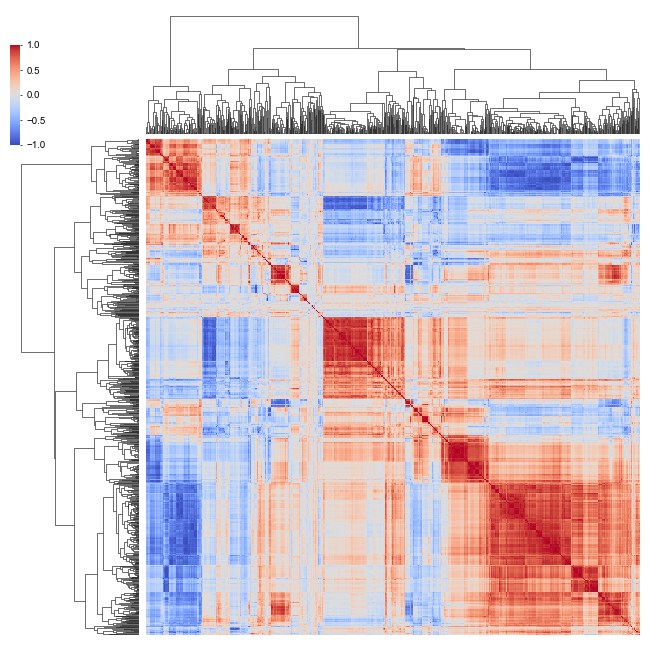

In [4]:
# Heatmap for radiomic feature correlation - for ICL cohort only

from seaborn import clustermap
import matplotlib.pyplot as plt

df_harm = harmoniser(df_merge, radiomic_features, "Manufacturer", reference_batch="SIEMENS")

df_harm_icl = df_harm[df_harm["Centre"]=="ICL"]

mm_inch = 1/25.4
figure = plt.figure(figsize=(88*mm_inch, 88*mm_inch))

# Create cluster map of the correlation matrix of harmonized radiomic features for ICL cohort only

df_harm_icl = df_harm[df_harm["Centre"]=="ICL"]

ax = clustermap(df_harm_icl[radiomic_features].corr(), cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={"ticks": [-1, -0.5, 0, 0.5, 1]},
                 cbar_pos=(0.01, 0.85, 0.01, 0.1))
1
# # Customize the color bar
colorbar = ax.cax
colorbar.length = 0.5
colorbar.tick_params(labelsize=1, labelcolor='black', width=0.5, length=1.5)
for tick in colorbar.get_yticklabels():
    tick.set_fontsize(7)
    tick.set_fontname('Arial')

ax.ax_heatmap.set_xticks([])
ax.ax_heatmap.set_yticks([])

In [ ]:
# Correlation of radiomic feature clusters with clinical features 

import numpy as np
from numpy import nan
import pandas as pd
from src.data.preprocessing import mice_imputer

df_harm["One_Year_Mort"] = nan
df_harm["One_Year_Mort"] = np.where(((df_harm["OS_event"]==1) & (df_harm["OS"]<12)),1,df_harm["One_Year_Mort"])
df_harm["One_Year_Mort"] = np.where(((df_harm["OS_event"]==1) & (df_harm["OS"]>=12)),0,df_harm["One_Year_Mort"])
df_harm["One_Year_Mort"] = np.where(((df_harm["OS_event"]==0) & (df_harm["OS"]>=9)),0,df_harm["One_Year_Mort"])
df_harm_icl = df_harm[df_harm["Centre"]=="ICL"]

bloods = ["Total_bilirubin","INR","PLT","Albumin","Creatinine","AST","ALT","GGT","ALP","CRP","Neutrophils","Lymphocytes","AFP"]

df_imputed_icl = mice_imputer(df_harm_icl, bloods)

print(df_imputed_icl[bloods].isnull().sum())

df_imputed_icl["NLR"] = df_imputed_icl["Neutrophils"]/df_imputed_icl["Lymphocytes"]
df_imputed_icl["PLR"] = df_imputed_icl["PLT"]/df_imputed_icl["Lymphocytes"]

df_imputed_icl["albi_score"] = np.log10(df_imputed_icl["Total_bilirubin"]*0.66) - 0.0852*df_imputed_icl["Albumin"]
df_imputed_icl["albi_1"] = np.where(df_imputed_icl["albi_score"] <= -2.60, 1, 0)
df_imputed_icl["albi_2"] = np.where((df_imputed_icl["albi_score"] >-2.60) & (df_imputed_icl["albi_score"]<=-1.39), 1, 0)
df_imputed_icl["albi_3"] = np.where(df_imputed_icl["albi_score"] > -1.39, 1, 0)
df_imputed_icl["albi_grade"] = np.where(df_imputed_icl["albi_1"]==1, 1, np.where(df_imputed_icl["albi_2"]==1, 2, 3))

df_imputed_icl["crafity_crp"] = np.where(df_imputed_icl["CRP"]>=1, 1, 0)
df_imputed_icl["crafity_afp"] = np.where(df_imputed_icl["AFP"]>=100, 1, 0)
df_imputed_icl["crafity"] = df_imputed_icl["crafity_crp"] + df_imputed_icl["crafity_afp"]
df_imputed_icl["crafity_0"] = np.where(df_imputed_icl["crafity"]==0, 1, 0)
df_imputed_icl["crafity_1"] = np.where(df_imputed_icl["crafity"]==1, 1, 0)
df_imputed_icl["crafity_2"] = np.where(df_imputed_icl["crafity"]==2, 1, 0)

df_imputed_icl["BCLC_STAGE_A"] = np.where(df_imputed_icl["BCLC STAGE"]=="A",1,0)
df_imputed_icl["BCLC_STAGE_B"] = np.where(df_imputed_icl["BCLC STAGE"]=="B",1,0)
df_imputed_icl["BCLC_STAGE_C"] = np.where(df_imputed_icl["BCLC STAGE"]=="C",1,0)

df_imputed_icl["BCLC_STAGE_GRADE"] = np.where(df_imputed_icl["BCLC STAGE"]=="A",0, np.where(df_imputed_icl["BCLC STAGE"]=="B", 1, 2))

df_imputed_icl["Child-Pugh_Class_A"] = np.where(df_imputed_icl["Child-Pugh Class"]==1,1,0)
df_imputed_icl["Child-Pugh_Class_B"] = np.where(df_imputed_icl["Child-Pugh Class"]==2,1,0)
df_imputed_icl["Child-Pugh_Class_GRADE"] = np.where(df_imputed_icl["Child-Pugh Class"]==1,0,1)

df_imputed_icl["AFP_400"] = np.where(df_imputed_icl["AFP"]>400,1,0)


df_clinical_features_icl = df_imputed_icl[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                        "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","MTD(cm)",
                        "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","M (EXTRAHEP METS)",
                        "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                        "albi_3","crafity"]]

df_clinical_features_icl["BCLC_STAGE_C"] = np.where(df_clinical_features_icl["BCLC STAGE"]=="C",1,0)
df_clinical_features_icl["Child-Pugh_Class_B"] = np.where(df_clinical_features_icl["Child-Pugh Class"]==2,1,0)
df_clinical_features_icl["MTD>7"] = np.where(df_clinical_features_icl["MTD(cm)"]>7,1,0)
df_clinical_features_icl["AFP_400"] = np.where(df_clinical_features_icl["AFP"]>400,1,0)



# hierachical clustering of radiomic features 

from sklearn.cluster import AgglomerativeClustering

radiomic_features = df_harm.columns[:892]

radiomic_features = radiomic_features.drop(["Centroid_x","Centroid_y","Centroid_z","maxVoxHotSpotCorr_x","maxVoxHotSpotCorr_y","maxVoxHotSpotCorr_z","LabelID","HOC","nHOC","MSR"])

clustering = AgglomerativeClustering(n_clusters=3).fit(df_imputed_icl[radiomic_features])

df_imputed_icl["h_cluster"] = clustering.labels_

# correlate the clusters with clinical variables with statistics

clinical_variables_cat = ["albi_grade","PVT","Multiple_nodules","BCLC STAGE","Ascites","Encephalopathy","One_Year_Mort"]

clinical_variables_cont = ["AFP","MTD(cm)","NLR","PLR"]

from scipy.stats import chi2_contingency

cluster_correlations_cat = {}

for i in clinical_variables_cat:
    contingency_table = pd.crosstab(df_imputed_icl[i], df_imputed_icl["h_cluster"])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    cluster_correlations_cat[i] = (chi2, p, dof)

from scipy.stats import f_oneway

cluster_correlations_cont = {}

for i in clinical_variables_cont:
    cluster_correlations_cont[i] = f_oneway(df_imputed_icl[df_imputed_icl["h_cluster"]==0][i], df_imputed_icl[df_imputed_icl["h_cluster"]==1][i], df_imputed_icl[df_imputed_icl["h_cluster"]==2][i])

print(cluster_correlations_cont)

print(cluster_correlations_cat)

Total_bilirubin    0
INR                0
PLT                0
Albumin            0
Creatinine         0
AST                0
ALT                0
GGT                0
ALP                0
CRP                0
Neutrophils        0
Lymphocytes        0
AFP                0
dtype: int64


C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3007214395.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinical_features_icl["BCLC_STAGE_C"] = np.where(df_clinical_features_icl["BCLC STAGE"]=="C",1,0)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3007214395.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinical_features_icl["Child-Pugh_Class_B"] = np.where(df_clinical_features_icl["Child-Pugh Class"]==2,1,0)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\3007214395.py:57: Sett

{'AFP': F_onewayResult(statistic=0.17260922932379152, pvalue=0.841889752652746), 'MTD(cm)': F_onewayResult(statistic=9.382278935539407, pvalue=0.0002897837191640027), 'NLR': F_onewayResult(statistic=0.784178155516078, pvalue=0.46119394416396764), 'PLR': F_onewayResult(statistic=0.4343014214727273, pvalue=0.6497708314533632)}
{'albi_grade': (2.0450084175084173, 0.7274807375804808, 4), 'PVT': (1.173068181818182, 0.5562518659952611, 2), 'Multiple_nodules': (1.6797379197379196, 0.431767098539365, 2), 'BCLC STAGE': (3.3875114784205698, 0.4951872358073115, 4), 'Ascites': (1.9822050290135396, 0.3711672480796827, 2), 'Encephalopathy': (0.0, 1.0, 0), 'One_Year_Mort': (1.2918275418275416, 0.5241833397100204, 2)}


Total_bilirubin    0
INR                0
PLT                0
Albumin            0
Creatinine         0
AST                0
ALT                0
GGT                0
ALP                0
CRP                0
Neutrophils        0
Lymphocytes        0
AFP                0
dtype: int64
Remaining radiomic features: 60
(55, 60)
(55, 60)
(88, 60)


C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\2260222534.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\2260222534.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
C:\Users\mat2k\AppData\Local\Temp\ipykernel_15880\2260222534.py:50: SettingWithCopyWarni


LASSO Features
Best param: {'C': 0.3906939937054613}
12
Index(['AUC-CSH_LLL', 'FD_mean_LLL_25HUgl', 'AUC-CSH_LLH', 'FOS_Imedian_LHL',
       'FOS_CV_LHH', 'AUC-CSH_LHH', 'FOS_Imedian_HLL',
       'GLCM_InfCo1_HHL_25HUgl', 'FOS_Imean_HHH', 'GLCM_ClShad_HHH_25HUgl',
       'Flatness3D', 'AreaDensityAEE_3D'],
      dtype='object')

Elastic Net Features
Best param: {'C': 0.3906939937054613, 'l1_ratio': 1.0}
12
Index(['AUC-CSH_LLL', 'FD_mean_LLL_25HUgl', 'AUC-CSH_LLH', 'FOS_Imedian_LHL',
       'FOS_CV_LHH', 'AUC-CSH_LHH', 'FOS_Imedian_HLL',
       'GLCM_InfCo1_HHL_25HUgl', 'FOS_Imean_HHH', 'GLCM_ClShad_HHH_25HUgl',
       'Flatness3D', 'AreaDensityAEE_3D'],
      dtype='object')

RFE Features
[False  True False  True False False False False False False False False
 False False False False  True False False False False False False False
 False False False False False False False False False False False False
 False False  True False False False False  True False  True False False
 False Fa

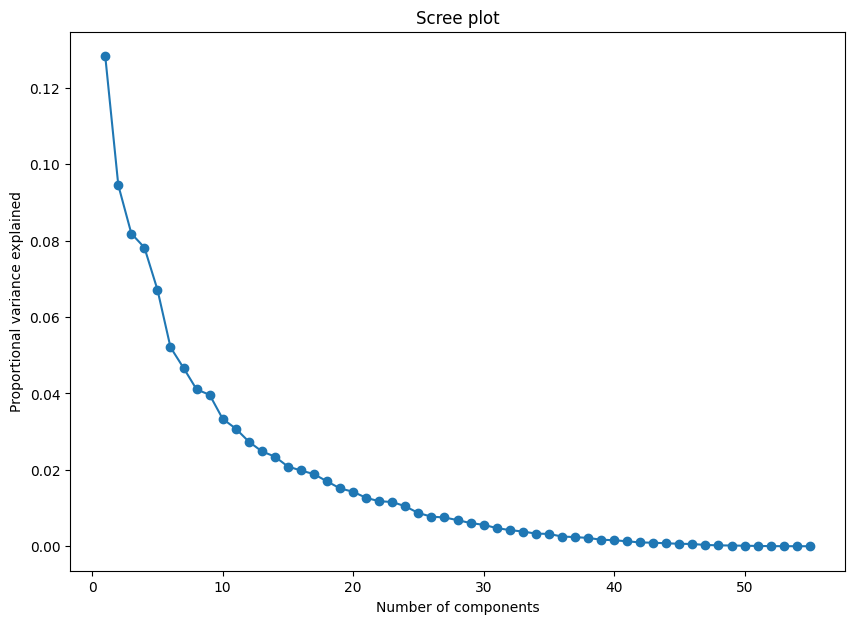


PCA Features
60
['FD_max_25HUgl' 'AUC-CSH_LLL' 'GLRLM_LRLGLE_LLL_25HUgl'
 'FD_mean_LLL_25HUgl' 'FD_lacunarity_LLL_25HUgl'
 'GLCM_AutoCorrel_LLL_25HUgl' 'AUC-CSH_LLH' 'GLCM_InfCo2_LLH_25HUgl'
 'FOS_Imedian_LHL' 'AUC-CSH_LHL' 'GLRLM_LRLGLE_LHL_25HUgl'
 'FD_max_LHL_25HUgl' 'GLCM_InfCo2_LHL_25HUgl' 'FOS_CV_LHH' 'FOS_Imean_LHH'
 'FOS_Imedian_LHH' 'AUC-CSH_LHH' 'GLCM_InfCo2_LHH_25HUgl'
 'FOS_Imedian_HLL' 'AUC-CSH_HLL' 'FD_max_HLL_25HUgl' 'FOS_CV_HLH'
 'FOS_Imean_HLH' 'FOS_Imedian_HLH' 'AUC-CSH_HLH' 'FOS_CV_HHL'
 'FOS_Imedian_HHL' 'AUC-CSH_HHL' 'GLCM_InfCo1_HHL_25HUgl'
 'GLCM_InfCo2_HHL_25HUgl' 'FOS_CV_HHH' 'FOS_Imean_HHH' 'FOS_Imedian_HHH'
 'AUC-CSH_HHH' 'GLCM_InfCo2_HHH_25HUgl' 'GLCM_ClShad_HHH_25HUgl'
 'GLCM_MxProb_HHH_25HUgl' 'GLCM_ClTend_HHH_25HUgl' 'GLCM_IDN_HHH_25HUgl'
 'CentreOfMassShift3D' 'MajorAxisLength3D' 'Flatness3D'
 'AreaDensityAABB_3D' 'AreaDensityAEE_3D' 'VolumeDensityConvexHull3D'
 'AreaDensityConvexHull3D' 'IntensityEnergy3D' 'RootMeanSquare3D'
 'IntensityHistogramQuartil

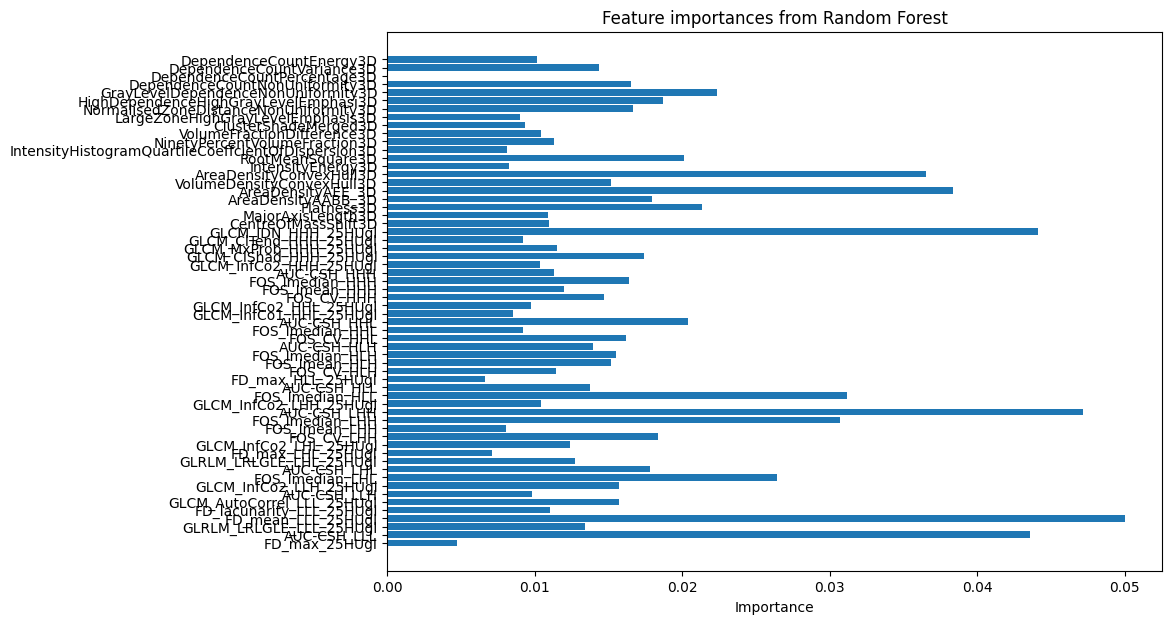


Random Forest Features
59
Index(['FD_max_25HUgl', 'AUC-CSH_LLL', 'GLRLM_LRLGLE_LLL_25HUgl',
       'FD_mean_LLL_25HUgl', 'FD_lacunarity_LLL_25HUgl',
       'GLCM_AutoCorrel_LLL_25HUgl', 'AUC-CSH_LLH', 'GLCM_InfCo2_LLH_25HUgl',
       'FOS_Imedian_LHL', 'AUC-CSH_LHL', 'GLRLM_LRLGLE_LHL_25HUgl',
       'FD_max_LHL_25HUgl', 'GLCM_InfCo2_LHL_25HUgl', 'FOS_CV_LHH',
       'FOS_Imean_LHH', 'FOS_Imedian_LHH', 'AUC-CSH_LHH',
       'GLCM_InfCo2_LHH_25HUgl', 'FOS_Imedian_HLL', 'AUC-CSH_HLL',
       'FD_max_HLL_25HUgl', 'FOS_CV_HLH', 'FOS_Imean_HLH', 'FOS_Imedian_HLH',
       'AUC-CSH_HLH', 'FOS_CV_HHL', 'FOS_Imedian_HHL', 'AUC-CSH_HHL',
       'GLCM_InfCo1_HHL_25HUgl', 'GLCM_InfCo2_HHL_25HUgl', 'FOS_CV_HHH',
       'FOS_Imean_HHH', 'FOS_Imedian_HHH', 'AUC-CSH_HHH',
       'GLCM_InfCo2_HHH_25HUgl', 'GLCM_ClShad_HHH_25HUgl',
       'GLCM_MxProb_HHH_25HUgl', 'GLCM_ClTend_HHH_25HUgl',
       'GLCM_IDN_HHH_25HUgl', 'CentreOfMassShift3D', 'MajorAxisLength3D',
       'Flatness3D', 'AreaDensityAABB_3D

In [17]:
# Generate feature selection to predict 1-year overall survival after therapy

from src.model_builder.feature_selection import standardise_features, remove_correlated_features, feature_selector

df_imputed = mice_imputer(df_harm, bloods)

print(df_imputed[bloods].isnull().sum())

df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)

df_imputed["AFP_400"] = np.where(df_imputed["AFP"]>400,1,0)

df_imputed["Response"] = np.where(df_imputed["Best Response (RECIST)"]<3,1,0)

df_imputed["Response"] = np.where(df_imputed["Best Response (RECIST)"].isna(),nan,df_imputed["Response"])


df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                        "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","MTD(cm)",
                        "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","M (EXTRAHEP METS)",
                        "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                        "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)


X_train = df_imputed[radiomic_features].loc[df_imputed["Centre"]=="ICL"][df_imputed["One_Year_Mort"].notna()]
y_train = df_imputed["One_Year_Mort"][df_imputed["One_Year_Mort"].notna()][df_imputed["Centre"]=="ICL"]
X_test = df_imputed[radiomic_features].loc[df_imputed["Centre"]=="ABR"][df_imputed["One_Year_Mort"].notna()]
y_test = df_imputed["One_Year_Mort"][df_imputed["One_Year_Mort"].notna()][df_imputed["Centre"]=="ABR"]

X_train_corr = remove_correlated_features(X_train[radiomic_features], radiomic_features, 0.7)

print(X_train_corr.shape)

X_train_standard, X_test_standard = standardise_features(X_train_corr, X_test[X_train_corr.columns], X_train_corr.columns)

print(X_train_standard.shape)
print(X_test_standard.shape)

radiomic_selected_features_dict = feature_selector(X_train_standard[X_train_corr.columns], y_train)

print(radiomic_selected_features_dict)


In [7]:
# Save Feature table to csv

from src.model_builder.feature_selection import feature_table

#feature_table(radiomic_selected_features_dict, r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\radiomic_feature_selection.csv")

In [8]:
# Train machine learning algorithms with feature sets using radiomic features

from src.model_builder.ml_prediction import ml_trainer

radiomic_ml = ml_trainer()

radiomic_ml.trainer(X_train_standard, y_train, X_test_standard, y_test, radiomic_selected_features_dict)

print(radiomic_ml.results)        

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

[{'feature_set': 'All', 'results': [{'model': 'Logistic Regression', 'best_parameters': {'C': 0.1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}, 'model_instance': GridSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=42),
             estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10]},
             scoring=make_scorer(roc_auc_score, needs_proba=True)), 'roc_auc_train': 0.975975975975976, 'roc_auc_val': 0.6861861861861862, 'roc_auc_test': 0.628099173553719, 'f1_train': 0.8, 'f1_val': 0.3225806451612903, 'f1_test': 0.37499999999999994, 'recall_train': 0.6666666666666666, 'recall_val': 0.2777777777777778, 'recall_test': 0.2727272727272727, 'precision_train': 1.0, 'precision_val': 0.38461538461538464,

In [10]:
# Evaluate the results of the machine learning and feature selection models

from src.model_builder.ml_prediction import ml_evaluator

radiomic_ml_eval = ml_evaluator(radiomic_ml.results)

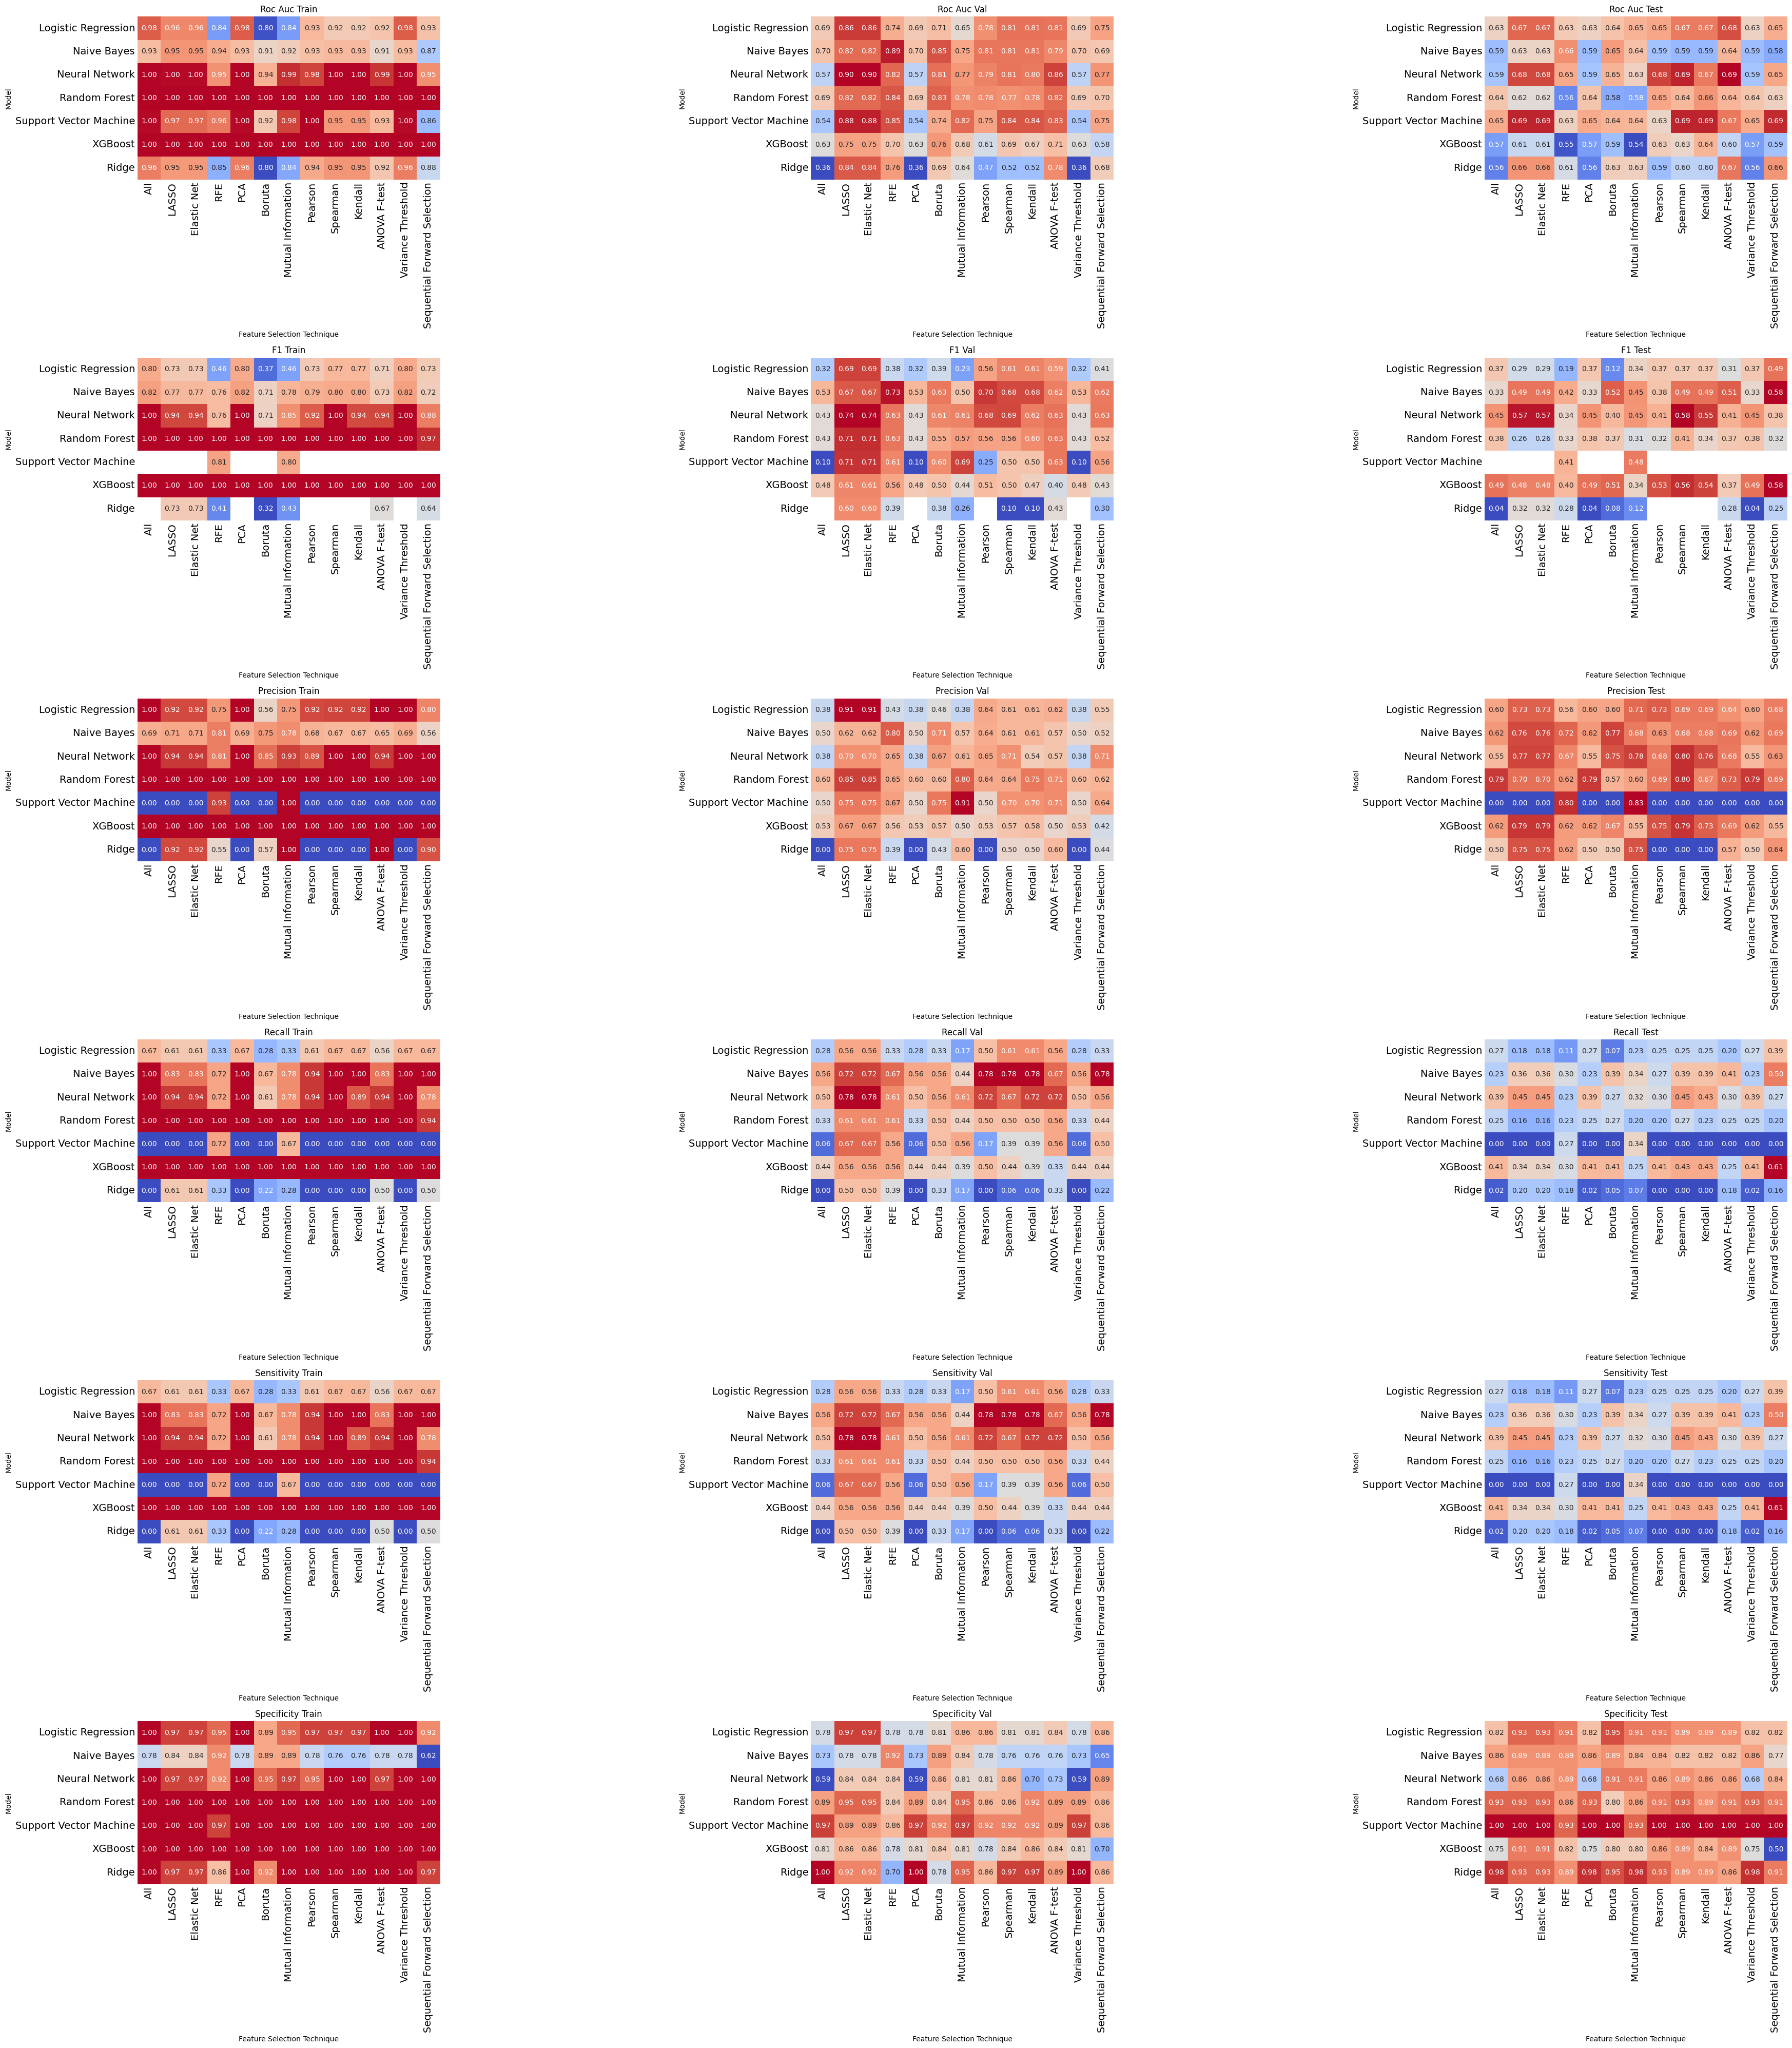

In [11]:
# Heatmap showing result of ML and feature selection predictions for 1-year OS

radiomic_ml_eval.results_heatmap()

In [ ]:
# Rank best performing feature selection techniques - by average across all ML models

radiomic_ml_eval.ranked_feature_selection_performance()

[(0.8393393393393394, 'LASSO'), (0.8393393393393394, 'Elastic Net'), (0.7989060489060489, 'RFE'), (0.7987987987987989, 'ANOVA F-test'), (0.76994851994852, 'Boruta'), (0.7508580008580008, 'Spearman'), (0.7479622479622481, 'Kendall'), (0.7251179751179752, 'Mutual Information'), (0.7124624624624625, 'Pearson'), (0.7030244530244529, 'Sequential Forward Selection'), (0.596096096096096, 'Variance Threshold'), (0.596096096096096, 'PCA'), (0.596096096096096, 'All')]


In [13]:
# Rank best performing ML models - by average across all feature sets

radiomic_ml_eval.ranked_model_performance()

[(0.7778355278355279, 'Naive Bayes'), (0.7692885192885193, 'Random Forest'), (0.7651882651882651, 'Neural Network'), (0.7567567567567568, 'Logistic Regression'), (0.7534650034650036, 'Support Vector Machine'), (0.6773504273504274, 'XGBoost'), (0.6015246015246014, 'Ridge')]


In [14]:
# Rank top 3 combinations

radiomic_ml_eval.top_3_combinations()

Best model: Neural Network with feature selection technique: LASSO, val_auc: 0.8978978978978979
Second best model: Naive Bayes with feature selection technique: RFE, val_auc: 0.8858858858858859
Third best model: Support Vector Machine with feature selection technique: LASSO, val_auc: 0.8843843843843844


In [15]:
# Ensemble the top 3 combinations

ensemble_model_metrics = radiomic_ml_eval.ensemble_top_3(X_train_standard, y_train, X_test_standard, y_test, feature_dict=radiomic_selected_features_dict)

e:\Box\One Drive To Box Migration\CT Immunotherapy\Analysis\python_codes\ICL_APHP_Radiomics\.venv38\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



Model 1
('Neural Network', 'LASSO')
[(0.9984984984984986, 0.9912280701754387, 1.0)]
[(0.8978978978978979, 0.7815126050420168, 0.9758064516129032)]
[(0.6807851239669421, 0.5693354264782836, 0.7893098079916969)]

Model 2
('Naive Bayes', 'RFE')
[(0.93993993993994, 0.8736559139784946, 0.988795518207283)]
[(0.8858858858858859, 0.7871428571428571, 0.9666666666666667)]
[(0.6590909090909091, 0.5374677002583979, 0.7781250000000001)]

Model 3
('Support Vector Machine', 'LASSO')
[(0.9714714714714714, 0.925, 0.998062015503876)]
[(0.8843843843843844, 0.7685714285714286, 0.9641873278236914)]
[(0.6885330578512397, 0.5744680851063829, 0.7949380165289256)]

Ensemble Model
[(0.9834834834834835, 0.9504643962848297, 1.0)]
[(0.903903903903904, 0.7944250871080138, 0.9798534798534799)]
[(0.6900826446280992, 0.5692708333333334, 0.7991696938245978)]


In [16]:
# Prediction of non-response

X_train_response = X_train.join(df_imputed["Response"])

X_train_response["No_response"] = 1 - X_train_response["Response"]

X_train_response["Rad_proba"] = ensemble_model_metrics["ensemble_model"]["train_proba"][0]

print(f'Train Non-Response Score: {roc_auc_score(X_train_response[X_train_response["No_response"].notna()]["No_response"],X_train_response[X_train_response["No_response"].notna()]["Rad_proba"])}')

X_test_response = X_test.join(df_imputed["Response"])

X_test_response["No_response"] = 1 - X_test_response["Response"]

X_test_response["Rad_proba"] = ensemble_model_metrics["ensemble_model"]["test_proba"][0]

print(f'Test Non-Response Score: {roc_auc_score(X_test_response[X_test_response["No_response"].notna()]["No_response"],X_test_response[X_test_response["No_response"].notna()]["Rad_proba"])}')

KeyError: 'Response'

In [ ]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models

X_test_km = X_test.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_km["Ensemble_label"]=ensemble_model_metrics["ensemble_model"]["y_pred_test_label"][0]
X_test_km["Ensemble_proba"]=ensemble_model_metrics["ensemble_model"]["test_proba"][0]

X_train_km = X_train.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_km["Ensemble_label"]=ensemble_model_metrics["ensemble_model"]["y_pred_train_label"][0]
X_train_km["Ensemble_proba"]=ensemble_model_metrics["ensemble_model"]["train_proba"][0]


# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])

X_test_km["cluster"] = model.predict(X_test_km[["Ensemble_proba"]])
X_train_km["cluster"] = model.predict(X_train_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_km["OS_event"], X_train_km["OS"], X_train_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_km["OS_event"], X_test_km["OS"], X_test_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_km["PFS_event"], X_train_km["PFS"], X_train_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_km["PFS_event"], X_test_km["PFS"], X_test_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
from sklearn.cluster import KMeans

# ensemble survival curve using youden index cut-off for top 3 models

X_test_km = X_test.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_km["Ensemble_label"]=ensemble_model_metrics["ensemble_model"]["y_pred_test_label"][0]
X_test_km["Ensemble_proba"]=ensemble_model_metrics["ensemble_model"]["test_proba"][0]

X_train_km = X_train.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_km["Ensemble_label"]=ensemble_model_metrics["ensemble_model"]["y_pred_train_label"][0]
X_train_km["Ensemble_proba"]=ensemble_model_metrics["ensemble_model"]["train_proba"][0]

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])

X_test_km["cluster"] = model.predict(X_test_km[["Ensemble_proba"]])
X_train_km["cluster"] = model.predict(X_train_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_km["OS_event"], X_train_km["OS"], X_train_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_km["OS_event"], X_test_km["OS"], X_test_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_km["PFS_event"], X_train_km["PFS"], X_train_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_km["PFS_event"], X_test_km["PFS"], X_test_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


# Clinical features for Cox Regression
df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)

df_imputed["HBV"] = np.where(df_imputed["HBV"]==1,1,0)
df_imputed["HCV"] = np.where(df_imputed["HCV"]==1,1,0)
df_imputed["EtOH"] = np.where(df_imputed["EtOH"]==1,1,0)
df_imputed["NASH"] = np.where(df_imputed["NASH"]==1,1,0)
df_imputed["Cirrhosis"] = np.where(df_imputed["Cirrhosis"]==1,1,0)

df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                          "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","Child-Pugh_Class_GRADE", "MTD(cm)",
                          "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","BCLC_STAGE_GRADE","M (EXTRAHEP METS)",
                          "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                          "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)

# Adding clinical variables to train set

X_train_cox = X_train_km.join(df_clinical_features)

# df_train_cluster_clinical.head()

# Adding clinical variables to test set

X_test_cox = X_test_km.join(df_clinical_features)


# HCC predictors for OS - univariate test set

clinical_predictors_cox = ["BCLC_STAGE_GRADE","BCLC_STAGE_C","Child-Pugh_Class_B","Child-Pugh_Class_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","crafity",
                       "albi_1","albi_2","albi_3","albi_grade",
                       "Ensemble_proba","cluster"]

print(cox_univariate(X_test_cox, clinical_predictors_cox, "OS_event", "OS"))

print(cox_univariate(X_test_cox, clinical_predictors_cox, "PFS_event", "PFS"))


In [ ]:
# Clinical variables for a clinical predicting model

clinical_predictors_cont = ["NLR","PLR","AFP","MTD(cm)","Age","bmi"]

clinical_predictors_cat = ["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)",
                           "Multiple_nodules","albi_grade"]

clinical_predictors = clinical_predictors_cont + clinical_predictors_cat

X_train_standard_clinical_cont, X_test_standard_clinical_cont = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_test.index], clinical_predictors_cont)

print(X_train_standard_clinical_cont.shape)
print(X_test_standard_clinical_cont.shape)

X_train_standard_clinical = X_train_standard_clinical_cont.join(df_imputed[clinical_predictors_cat])
X_test_standard_clinical = X_test_standard_clinical_cont.join(df_imputed[clinical_predictors_cat])

print(X_train_standard_clinical.shape)
print(X_test_standard_clinical.shape)

clinical_selected_features_dict = feature_selector(X_train_standard_clinical, y_train)

print(clinical_selected_features_dict)


In [ ]:
# Save Feature table to csv

feature_table(clinical_selected_features_dict, r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\clinical_feature_selection.csv")

In [ ]:
clinical_ml = ml_trainer()

clinical_ml.trainer(X_train_standard_clinical, y_train, X_test_standard_clinical, y_test, clinical_selected_features_dict)

print(clinical_ml.results)        

In [ ]:
clinical_ml_eval = ml_evaluator(clinical_ml.results)

clinical_ml_eval.results_heatmap()

In [ ]:
clinical_ml_eval.top_3_combinations()

ensemble_model_metrics_clinical = clinical_ml_eval.ensemble_top_3(X_train_standard_clinical, y_train, X_test_standard_clinical, y_test, feature_dict=clinical_selected_features_dict)

In [ ]:
# Prediction of non-response

X_train_response = X_train.join(df_imputed["Response"])

X_train_response["No_response"] = 1 - X_train_response["Response"]

X_train_response["Rad_proba"] = ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0]

print(f'Train Non-Response Score: {roc_auc_score(X_train_response[X_train_response["No_response"].notna()]["No_response"],X_train_response[X_train_response["No_response"].notna()]["Rad_proba"])}')

X_test_response = X_test.join(df_imputed["Response"])

X_test_response["No_response"] = 1 - X_test_response["Response"]

X_test_response["Rad_proba"] = ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0]

print(f'Test Non-Response Score: {roc_auc_score(X_test_response[X_test_response["No_response"].notna()]["No_response"],X_test_response[X_test_response["No_response"].notna()]["Rad_proba"])}')

In [ ]:
from sklearn.cluster import KMeans

# ensemble survival curve using youden index cut-off for top 3 models

X_test_clinical_km = X_test_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_clinical_km["Ensemble_label"]=ensemble_model_metrics_clinical["ensemble_model"]["y_pred_test_label"][0]
X_test_clinical_km["Ensemble_proba"]=ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0]

X_train_clinical_km = X_train_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_clinical_km["Ensemble_label"]=ensemble_model_metrics_clinical["ensemble_model"]["y_pred_train_label"][0]
X_train_clinical_km["Ensemble_proba"]=ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0]


# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_clinical_km[["Ensemble_proba"]])

X_test_clinical_km["cluster"] = model.predict(X_test_clinical_km[["Ensemble_proba"]])
X_train_clinical_km["cluster"] = model.predict(X_train_clinical_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_clinical_km["OS_event"], X_train_clinical_km["OS"], X_train_clinical_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_clinical_km["OS_event"], X_test_clinical_km["OS"], X_test_clinical_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_clinical_km["PFS_event"], X_train_clinical_km["PFS"], X_train_clinical_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_clinical_km["PFS_event"], X_test_clinical_km["PFS"], X_test_clinical_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
from sklearn.cluster import KMeans

# ensemble survival curve using youden index cut-off for top 3 models

X_test_clinical_km = X_test_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_clinical_km["Ensemble_label"]=ensemble_model_metrics_clinical["ensemble_model"]["y_pred_test_label"][0]
X_test_clinical_km["Ensemble_proba"]=ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0]

X_train_clinical_km = X_train_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_clinical_km["Ensemble_label"]=ensemble_model_metrics_clinical["ensemble_model"]["y_pred_train_label"][0]
X_train_clinical_km["Ensemble_proba"]=ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0]


# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_clinical_km[["Ensemble_proba"]])

X_test_clinical_km["cluster"] = model.predict(X_test_clinical_km[["Ensemble_proba"]])
X_train_clinical_km["cluster"] = model.predict(X_train_clinical_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_clinical_km["OS_event"], X_train_clinical_km["OS"], X_train_clinical_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_clinical_km["OS_event"], X_test_clinical_km["OS"], X_test_clinical_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_clinical_km["PFS_event"], X_train_clinical_km["PFS"], X_train_clinical_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_clinical_km["PFS_event"], X_test_clinical_km["PFS"], X_test_clinical_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


# Clinical features for Cox Regression
df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)


df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                          "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","Child-Pugh_Class_GRADE","MTD(cm)",
                          "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","BCLC_STAGE_GRADE","M (EXTRAHEP METS)",
                          "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                          "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)

# Adding clinical variables to train set

X_train_clinical_km_cox = X_train_clinical_km.join(df_clinical_features, lsuffix="_train")

# df_train_cluster_clinical.head()

# Adding clinical variables to test set

X_test_clinical_km_cox = X_test_clinical_km.join(df_clinical_features, lsuffix="_test")


# HCC predictors for OS - univariate test set

clinical_predictors_cox = ["BCLC_STAGE_GRADE","BCLC_STAGE_C","Child-Pugh_Class_B","Child-Pugh_Class_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","crafity",
                       "albi_1","albi_2","albi_3","albi_grade",
                       "Ensemble_proba","cluster"]

print(cox_univariate(X_test_clinical_km_cox, clinical_predictors_cox, "OS_event", "OS"))

print(cox_univariate(X_test_clinical_km_cox, clinical_predictors_cox, "PFS_event", "PFS"))

In [ ]:
       # Get the features selected by Best Method
from sklearn.metrics import precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_predict, StratifiedKFold

y_pred_train_proba = (ensemble_model_metrics["ensemble_model"]["train_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0])/2
y_pred_val_proba = (ensemble_model_metrics["ensemble_model"]["val_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["val_proba"][0])/2
y_pred_test_proba = (ensemble_model_metrics["ensemble_model"]["test_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0])/2

y_train_mod = ensemble_model_metrics["ensemble_model"]["train_truth"][0]
y_val_mod = ensemble_model_metrics["ensemble_model"]["train_truth"][0]
y_test_mod = ensemble_model_metrics["ensemble_model"]["test_truth"][0]

# Calculate the ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train_mod, y_pred_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val_mod, y_pred_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test_mod, y_pred_test_proba)

# Get ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train_mod, y_pred_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val_mod, y_pred_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test_mod, y_pred_test_proba)

auc_train = compute_auc_ci(y_train_mod, y_pred_train_proba)
auc_val = compute_auc_ci(y_val_mod, y_pred_val_proba)
auc_test = compute_auc_ci(y_test_mod, y_pred_test_proba)

youden_index = sensivity_specifity_cutoff(y_val_mod, y_pred_val_proba)

y_pred_train_label = np.array(y_pred_train_proba > youden_index).astype(int)
y_pred_val_label = np.array(y_pred_val_proba > youden_index).astype(int)
y_pred_test_label = np.array(y_pred_test_proba > youden_index).astype(int)

ensemble_model_metrics_radioclinical = {}

ensemble_model_metrics_radioclinical = {"ensemble_model":{
            "model_name":"ensemble",
            "feature_set_name":"ensemble",
            "train_truth":[y_train_mod],
            "val_truth":[y_val_mod],
            "test_truth":[y_test_mod],
            "train_proba":[y_pred_train_proba],
            "val_proba":[y_pred_val_proba],
            "test_proba":[y_pred_test_proba],
            "train_auc":[auc_train],
            "val_auc":[auc_val],
            "test_auc":[auc_test],
            "train_fpr":[fpr_train],
            "train_tpr":[tpr_train],
            "val_fpr":[fpr_val],
            "val_tpr":[tpr_val],
            "test_fpr":[fpr_test],
            "test_tpr":[tpr_test],
            "youden_index":[youden_index],
            "y_pred_train_label":[y_pred_train_label],
            "y_pred_val_label":[y_pred_val_label],
            "y_pred_test_label":[y_pred_test_label],
            "feature_importance":{"Radiomic":ensemble_model_metrics["ensemble_model"]["feature_importance"], "Clinical":ensemble_model_metrics_clinical["ensemble_model"]["feature_importance"]},
            }}

In [ ]:
feature_importance_table = {}

for i in ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"].keys():
    print(i)
    for j in ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"][i].keys():
        print(j)
        model_set = i + "_" + j
        feature_importance_table[model_set] = np.round(abs(pd.DataFrame(ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"][i][j], index=[0]).transpose()).sort_values(by=0, ascending=False),4)
        feature_importance_table[model_set].columns = [model_set]

In [ ]:
feature_importance_table["Radiomic_model_3"]

In [ ]:
feature_importance_table = {}

for i in ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"].keys():
    print(i)
    for j in ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"][i].keys():
        print(j)
        model_set = i + "_" + j
        feature_importance_table[model_set] = np.round((pd.DataFrame(ensemble_model_metrics_radioclinical["ensemble_model"]["feature_importance"][i][j], index=[0]).transpose()).sort_values(by=0, ascending=False),4)
        feature_importance_table[model_set].columns = [model_set]

In [ ]:
feature_importance_table["Clinical_model_3"]

In [ ]:
# Combined clinical and radiomic model

X_test_radio_clinical_km = X_test_standard.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_km["Ensemble_proba"]=(ensemble_model_metrics["ensemble_model"]["test_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0])/2

X_train_radio_clinical_km = X_train_standard.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_km["Ensemble_proba"]=(ensemble_model_metrics["ensemble_model"]["train_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0])/2

X_val_radio_clinical_km = X_train_standard.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_val_radio_clinical_km["Ensemble_proba"]=(ensemble_model_metrics["ensemble_model"]["val_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["val_proba"][0])/2

# calculate ROC values
def compute_auc_ci(y_true, y_score, n_bootstraps=1000, alpha=0.05, random_state=42):

    import numpy as np 

    from sklearn.utils import resample
    from scipy.stats import sem, t
    from sklearn.metrics import roc_auc_score

    """
    Compute the AUC and its confidence interval using bootstrapping.
    
    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        True binary labels.
    y_score : array-like of shape (n_samples,)
        Target scores.
    n_bootstraps : int, default=1000
        Number of bootstraps.
    alpha : float, default=0.05
        Confidence level (e.g., 0.05 for a 95% confidence interval).
    
    Returns
    -------
    auc : float
        AUC score.
    ci_lower : float
        Lower bound of the confidence interval.
    ci_upper : float
        Upper bound of the confidence interval.
    """
    assert len(y_true) == len(y_score), "Lengths of y_true and y_score should be equal."
    
    auc = roc_auc_score(y_true, y_score)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Bootstrap by sampling with replacement
        y_true_resampled, y_score_resampled = resample(y_true, y_score, random_state=random_state+_)
        score = roc_auc_score(y_true_resampled, y_score_resampled)
        bootstrapped_scores.append(score)
    
    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    
    # Compute the lower and upper bound of the confidence interval
    confidence_lower = sorted_scores[int((alpha / 2.0) * n_bootstraps)]
    confidence_upper = sorted_scores[int((1 - alpha / 2.0) * n_bootstraps)]
    
    return auc, confidence_lower, confidence_upper

auc_train = compute_auc_ci(y_train, X_train_radio_clinical_km["Ensemble_proba"])
auc_val = compute_auc_ci(y_train, X_val_radio_clinical_km["Ensemble_proba"])
auc_test = compute_auc_ci(y_test, X_test_radio_clinical_km["Ensemble_proba"])

print(auc_train)
print(auc_val)
print(auc_test)

In [ ]:
# Prediction of non-response

X_train_response = X_train.join(df_imputed["Response"])

X_train_response["No_response"] = 1 - X_train_response["Response"]

X_train_response["Rad_proba"] = ensemble_model_metrics_radioclinical["ensemble_model"]["train_proba"][0]

print(f'Train Non-Response Score: {roc_auc_score(X_train_response[X_train_response["No_response"].notna()]["No_response"],X_train_response[X_train_response["No_response"].notna()]["Rad_proba"])}')

X_test_response = X_test.join(df_imputed["Response"])

X_test_response["No_response"] = 1 - X_test_response["Response"]

X_test_response["Rad_proba"] = ensemble_model_metrics_radioclinical["ensemble_model"]["test_proba"][0]

print(f'Test Non-Response Score: {roc_auc_score(X_test_response[X_test_response["No_response"].notna()]["No_response"],X_test_response[X_test_response["No_response"].notna()]["Rad_proba"])}')

In [ ]:
# Combined clinical and radiomic model

X_test_radio_clinical_km = X_test_standard.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_km["Ensemble_proba"]=(ensemble_model_metrics["ensemble_model"]["test_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["test_proba"][0])/2
X_test_radio_clinical_km["Ensemble_label"]=ensemble_model_metrics_radioclinical["ensemble_model"]["y_pred_test_label"][0]

X_train_radio_clinical_km = X_train_standard.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_km["Ensemble_proba"]=(ensemble_model_metrics["ensemble_model"]["train_proba"][0] + ensemble_model_metrics_clinical["ensemble_model"]["train_proba"][0])/2
X_train_radio_clinical_km["Ensemble_label"]=ensemble_model_metrics_radioclinical["ensemble_model"]["y_pred_train_label"][0]

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_km["cluster"] = model.predict(X_test_radio_clinical_km[["Ensemble_proba"]])
X_train_radio_clinical_km["cluster"] = model.predict(X_train_radio_clinical_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_km["OS_event"], X_train_radio_clinical_km["OS"], X_train_radio_clinical_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_km["OS_event"], X_test_radio_clinical_km["OS"], X_test_radio_clinical_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_km["PFS_event"], X_train_radio_clinical_km["PFS"], X_train_radio_clinical_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_km["PFS_event"], X_test_radio_clinical_km["PFS"], X_test_radio_clinical_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index


# Clinical features for Cox Regression
df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)


df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                          "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh_Class_GRADE","Child-Pugh Class","MTD(cm)",
                          "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","BCLC_STAGE_GRADE","M (EXTRAHEP METS)",
                          "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                          "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)

# Adding clinical variables to train set
X_train_radio_clinical_km_cox = X_train_radio_clinical_km.join(df_clinical_features, lsuffix="_train")

# df_train_cluster_clinical.head()

# Adding clinical variables to test set

X_test_radio_clinical_km_cox = X_test_radio_clinical_km.join(df_clinical_features, lsuffix="_test")

# HCC predictors for OS - univariate test set

clinical_predictors_cox = ["BCLC_STAGE_GRADE","BCLC_STAGE_C","Child-Pugh_Class_B","Child-Pugh_Class_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","crafity",
                       "albi_1","albi_2","albi_3","albi_grade",
                       "Ensemble_proba","cluster"]

print(cox_univariate(X_test_radio_clinical_km_cox, clinical_predictors_cox, "OS_event", "OS"))

print(cox_univariate(X_test_radio_clinical_km_cox, clinical_predictors_cox, "PFS_event", "PFS"))

In [ ]:
# retained_list = ['PLR', 'M (EXTRAHEP METS)', 'BCLC_STAGE_GRADE', 'PVT']
 
# # Combined radiomic and clinical - inputting the most important clinical features prior to feature selection

# X_train_standard_radioclinical = X_train_standard.join(df_imputed[retained_list])
# X_test_standard_radioclinical = X_test_standard.join(df_imputed[retained_list])

# radiomic_clinical_selected_features_dict = feature_selector(X_train_standard_radioclinical[X_train_standard_radioclinical.columns], y_train)

In [ ]:
# # Combined radiomic and clinical - inputting the most important clinical features prior to feature selection

# X_train_standard_radioclinical = X_train_standard.join(df_imputed[['PLR', 'BCLC_STAGE_GRADE', 'NLR', 'M (EXTRAHEP METS)']])
# X_test_standard_radioclinical = X_test_standard.join(df_imputed[['PLR', 'BCLC_STAGE_GRADE', 'NLR', 'M (EXTRAHEP METS)']])

# radiomic_clinical_selected_features_dict = feature_selector(X_train_standard_radioclinical[X_train_standard_radioclinical.columns], y_train)

In [ ]:
# # # Training the combined radiomic and clinical model with the selected features

# radiomic_clinical_ml = ml_trainer()

# radiomic_clinical_ml.trainer(X_train_standard_radioclinical, y_train, X_test_standard_radioclinical, y_test, radiomic_clinical_selected_features_dict)

# print(radiomic_clinical_ml.results)        

In [ ]:
# radiomic_clinical_ml_eval = ml_evaluator(radiomic_clinical_ml.results)

# radiomic_clinical_ml_eval.results_heatmap()

In [ ]:
# # # Evaluation of the combined radiomic and clinical model with the selected features

# radiomic_clinical_ml_eval.top_3_combinations()

# ensemble_model_metrics_joint_rc= radiomic_clinical_ml_eval.ensemble_top_3(X_train_standard_radioclinical, y_train, X_test_standard_radioclinical, y_test, feature_dict=radiomic_clinical_selected_features_dict)

In [ ]:
# from sklearn.cluster import KMeans

# # ensemble survival curve using youden index cut-off for top 3 models

# X_test_radio_clinical_feat_km = X_test_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
# X_test_radio_clinical_feat_km["Ensemble_label"]=ensemble_model_metrics_joint_rc["ensemble_model"]["y_pred_test_label"][0]
# X_test_radio_clinical_feat_km["Ensemble_proba"]=ensemble_model_metrics_joint_rc["ensemble_model"]["test_proba"][0]

# X_train_radio_clinical_feat_km = X_train_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
# X_train_radio_clinical_feat_km["Ensemble_label"]=ensemble_model_metrics_joint_rc["ensemble_model"]["y_pred_train_label"][0]
# X_train_radio_clinical_feat_km["Ensemble_proba"]=ensemble_model_metrics_joint_rc["ensemble_model"]["train_proba"][0]


# # Model using optimal cluster number from elbow plot

# model=KMeans(n_clusters=2, random_state=42)

# model.fit(X_train_radio_clinical_feat_km[["Ensemble_proba"]])

# X_test_radio_clinical_feat_km["cluster"] = model.predict(X_test_radio_clinical_feat_km[["Ensemble_proba"]])
# X_train_radio_clinical_feat_km["cluster"] = model.predict(X_train_radio_clinical_feat_km[["Ensemble_proba"]])

# fig = plt.figure(figsize=(20, 20))

# # Survival Curve - OS from internal validation set

# ax1=fig.add_subplot(2,2,1)
# km_curve_at_risk(X_train_radio_clinical_feat_km["OS_event"], X_train_radio_clinical_feat_km["OS"], X_train_radio_clinical_feat_km["cluster"], "Train OS", ax=ax1)

# ax2=fig.add_subplot(2,2,2)
# km_curve_at_risk(X_test_radio_clinical_feat_km["OS_event"], X_test_radio_clinical_feat_km["OS"], X_test_radio_clinical_feat_km["cluster"], "Test OS", ax=ax2)

# ax3=fig.add_subplot(2,2,3)
# km_curve_at_risk(X_train_radio_clinical_feat_km["PFS_event"], X_train_radio_clinical_feat_km["PFS"], X_train_radio_clinical_feat_km["cluster"], "Train PFS", ax=ax3)

# ax4=fig.add_subplot(2,2,4)
# km_curve_at_risk(X_test_radio_clinical_feat_km["PFS_event"], X_test_radio_clinical_feat_km["PFS"], X_test_radio_clinical_feat_km["cluster"], "Test PFS", ax=ax4)

# plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
# from sklearn.cluster import KMeans

# # ensemble survival curve using youden index cut-off for top 3 models

# X_test_radio_clinical_feat_km = X_test_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
# X_test_radio_clinical_feat_km["Ensemble_label"]=ensemble_model_metrics_joint_rc["ensemble_model"]["y_pred_test_label"][0]
# X_test_radio_clinical_feat_km["Ensemble_proba"]=ensemble_model_metrics_joint_rc["ensemble_model"]["test_proba"][0]

# X_train_radio_clinical_feat_km = X_train_standard_clinical.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
# X_train_radio_clinical_feat_km["Ensemble_label"]=ensemble_model_metrics_joint_rc["ensemble_model"]["y_pred_train_label"][0]
# X_train_radio_clinical_feat_km["Ensemble_proba"]=ensemble_model_metrics_joint_rc["ensemble_model"]["train_proba"][0]


# # Model using optimal cluster number from elbow plot

# model=KMeans(n_clusters=2, random_state=42)

# model.fit(X_train_radio_clinical_feat_km[["Ensemble_proba"]])

# X_test_radio_clinical_feat_km["cluster"] = model.predict(X_test_radio_clinical_feat_km[["Ensemble_proba"]])
# X_train_radio_clinical_feat_km["cluster"] = model.predict(X_train_radio_clinical_feat_km[["Ensemble_proba"]])

# fig = plt.figure(figsize=(20, 20))

# # Survival Curve - OS from internal validation set

# ax1=fig.add_subplot(2,2,1)
# km_curve_at_risk(X_train_radio_clinical_feat_km["OS_event"], X_train_radio_clinical_feat_km["OS"], X_train_radio_clinical_feat_km["Ensemble_label"], "Train OS", ax=ax1)

# ax2=fig.add_subplot(2,2,2)
# km_curve_at_risk(X_test_radio_clinical_feat_km["OS_event"], X_test_radio_clinical_feat_km["OS"], X_test_radio_clinical_feat_km["Ensemble_label"], "Test OS", ax=ax2)

# ax3=fig.add_subplot(2,2,3)
# km_curve_at_risk(X_train_radio_clinical_feat_km["PFS_event"], X_train_radio_clinical_feat_km["PFS"], X_train_radio_clinical_feat_km["Ensemble_label"], "Train PFS", ax=ax3)

# ax4=fig.add_subplot(2,2,4)
# km_curve_at_risk(X_test_radio_clinical_feat_km["PFS_event"], X_test_radio_clinical_feat_km["PFS"], X_test_radio_clinical_feat_km["Ensemble_label"], "Test PFS", ax=ax4)

# plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
# Benchmark clinical predictors using logistic regression

clinical_predictor = {}

for c in clinical_predictors:
    
    clinical_predictor[c]= custom_model_predictor(X_train=X_train_standard_clinical, y_train=y_train, X_test=X_test_standard_clinical, y_test=y_test, custom_model_name="Logistic Regression", custom_feature_set=[c], random_state=42)

    print(" ")
    print(c)
    print(clinical_predictor[c]["train_auc"])
    print(clinical_predictor[c]["val_auc"])
    print(clinical_predictor[c]["test_auc"])

In [ ]:
# Results table - showing all training, validation, test AUCs for radiomic, clinical and combined models

results_table = pd.DataFrame(columns=["Train AUC","Training p-value","Validation AUC","Validation p-value","Test AUC","Test p-value"])

for i in clinical_predictor:
       
        results_table.loc[i] = {"Train AUC":f'{clinical_predictor[i]["train_auc"][0][0]:.2f} ({clinical_predictor[i]["train_auc"][0][1]:.2f}, {clinical_predictor[i]["train_auc"][0][2]:.2f})',
                                            "Training p-value":f'{10**delong_roc_test(clinical_predictor[i]["train_truth"][0],X_train_clinical_km["Ensemble_proba"],clinical_predictor[i]["train_proba"][0])[0][0]:.3f}',
                                            "Validation AUC":f'{clinical_predictor[i]["val_auc"][0][0]:.2f} ({clinical_predictor[i]["val_auc"][0][1]:.2f}, {clinical_predictor[i]["val_auc"][0][2]:.2f})',
                                            "Validation p-value":f'{10**delong_roc_test(clinical_predictor[i]["val_truth"][0],X_train_clinical_km["Ensemble_proba"],clinical_predictor[i]["val_proba"][0])[0][0]:.3f}',
                                            "Test AUC":f'{clinical_predictor[i]["test_auc"][0][0]:.2f} ({clinical_predictor[i]["test_auc"][0][1]:.2f}, {clinical_predictor[i]["test_auc"][0][2]:.2f})',
                                            "Test p-value":f'{10**delong_roc_test(clinical_predictor[i]["test_truth"][0],X_test_clinical_km["Ensemble_proba"],clinical_predictor[i]["test_proba"][0])[0][0]:.3f}'}
        
results_table

In [ ]:
# Results table - showing all training, validation, test AUCs for radiomic, clinical and combined models - BCLC p value

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)
    
model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}


os_results_table = pd.DataFrame(columns=["Train AUC","Training p-value","Validation AUC","Validation p-value","Test AUC","Test p-value"])

for key, item in model_dictionaries.items():
        
        os_results_table.loc[key] = {"Train AUC":f'{school_round(item["train_auc"][0][0],2):.2f} ({school_round(item["train_auc"][0][1],2):.2f}, {school_round(item["train_auc"][0][2],2):.2f})',
                                            "Training p-value":f'{school_round(10**delong_roc_test(item["train_truth"][0],model_dictionaries["BCLC Stage"]["train_proba"][0],item["train_proba"][0])[0][0],3):.3f}',
                                            "Validation AUC":f'{school_round(item["val_auc"][0][0],2):.2f} ({school_round(item["val_auc"][0][1],2):.2f}, {school_round(item["val_auc"][0][2],2):.2f})',
                                            "Validation p-value":f'{school_round(10**delong_roc_test(item["val_truth"][0],model_dictionaries["BCLC Stage"]["val_proba"][0],item["val_proba"][0])[0][0],3):.3f}',
                                            "Test AUC":f'{school_round(item["test_auc"][0][0],2):.2f} ({school_round(item["test_auc"][0][1],2):.2f}, {school_round(item["test_auc"][0][2],2):.2f})',
                                            "Test p-value":f'{school_round(10**delong_roc_test(item["test_truth"][0],model_dictionaries["BCLC Stage"]["test_proba"][0],item["test_proba"][0])[0][0],2):.3f}'}
        
os_results_table["Model"] = os_results_table.index
os_results_table.insert(0, "Model", os_results_table.pop("Model"))
os_results_table.reset_index(drop=True, inplace=True)

os_results_table

In [ ]:
# Results table - showing all training, validation, test AUCs for radiomic, clinical and combined models - ALBI grade p value

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

os_results_table = pd.DataFrame(columns=["Train AUC","Training p-value","Validation AUC","Validation p-value","Test AUC","Test p-value"])

for key, item in model_dictionaries.items():
        
        os_results_table.loc[key] = {"Train AUC":f'{school_round(item["train_auc"][0][0],2):.2f} ({school_round(item["train_auc"][0][1],2):.2f}, {school_round(item["train_auc"][0][2],2):.2f})',
                                            "Training p-value":f'{school_round(10**delong_roc_test(item["train_truth"][0],model_dictionaries["Albi grade"]["train_proba"][0],item["train_proba"][0])[0][0],3):.3f}',
                                            "Validation AUC":f'{school_round(item["val_auc"][0][0],2):.2f} ({school_round(item["val_auc"][0][1],2):.2f}, {school_round(item["val_auc"][0][2],2):.2f})',
                                            "Validation p-value":f'{school_round(10**delong_roc_test(item["val_truth"][0],model_dictionaries["Albi grade"]["val_proba"][0],item["val_proba"][0])[0][0],3):.3f}',
                                            "Test AUC":f'{school_round(item["test_auc"][0][0],2):.2f} ({school_round(item["test_auc"][0][1],2):.2f}, {school_round(item["test_auc"][0][2],2):.2f})',
                                            "Test p-value":f'{school_round(10**delong_roc_test(item["test_truth"][0],model_dictionaries["Albi grade"]["test_proba"][0],item["test_proba"][0])[0][0],2):.3f}'}
        
os_results_table["Model"] = os_results_table.index
os_results_table.insert(0, "Model", os_results_table.pop("Model"))
os_results_table.reset_index(drop=True, inplace=True)

os_results_table

In [ ]:
clinical_predictor["BCLC_STAGE_GRADE"]

In [ ]:
#calculate precision-recall AUC, F1 score, precision, recall, sensitivity, specificity, accuracy for ensemble model

from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score, accuracy_score

def auc_pr(y_true, y_pred_proba):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    return auc(recall, precision)

metrics = {"auc_pr":  auc_pr, "precision": precision_score, "recall": recall_score, "f1_score":f1_score, "accuracy": accuracy_score}
threshold = 0.5

all_metric_results = {}

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

for i in metrics.keys():
    metric_results = {}
    for j in model_dictionaries.keys():
        if i == "auc_pr":
            metric_results[j] = {"training":metrics[i](model_dictionaries[j]["train_truth"][0], model_dictionaries[j]["train_proba"][0]),
            "validation":metrics[i](model_dictionaries[j]["val_truth"][0], model_dictionaries[j]["val_proba"][0]),
            "test":metrics[i](model_dictionaries[j]["test_truth"][0], model_dictionaries[j]["test_proba"][0])}
        elif i == "f1_score":
            metric_results[j] = {"training":metrics[i](model_dictionaries[j]["train_truth"][0], model_dictionaries[j]["train_proba"][0] > threshold, average="micro"),
            "validation":metrics[i](model_dictionaries[j]["val_truth"][0], model_dictionaries[j]["val_proba"][0] > threshold, average="micro"),
            "test":metrics[i](model_dictionaries[j]["test_truth"][0], model_dictionaries[j]["test_proba"][0] > threshold, average="micro")}
        else:
            metric_results[j] = {"training":metrics[i](model_dictionaries[j]["train_truth"][0], model_dictionaries[j]["train_proba"][0] > threshold),
            "validation":metrics[i](model_dictionaries[j]["val_truth"][0], model_dictionaries[j]["val_proba"][0] > threshold),
            "test":metrics[i](model_dictionaries[j]["test_truth"][0], model_dictionaries[j]["test_proba"][0] > threshold)}
    all_metric_results[i] = metric_results

for i in all_metric_results.keys():
    print(i)
    df = pd.DataFrame(all_metric_results[i])
    df = np.round(df,2).transpose()
    print(df)
    print("")

In [ ]:
# Output results to csv file - for each clinical parameter and each model with the mortality outcome

roc_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"],
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Integrated": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
"Albi grade": clinical_predictor["albi_grade"],
"Age": clinical_predictor["Age"],
"BMI": clinical_predictor["bmi"],
"AFP": clinical_predictor["AFP"],
"PLR": clinical_predictor["PLR"],
"NLR": clinical_predictor["NLR"],
"MTD": clinical_predictor["MTD(cm)"],
"PVT": clinical_predictor["PVT"],
"Multiple_nodules": clinical_predictor["Multiple_nodules"],
"Extrahepatic_metastasis": clinical_predictor["M (EXTRAHEP METS)"]}

roc_train_df = pd.DataFrame()
roc_train_df["mort_12"] = roc_dictionaries["Radiomic"]["train_truth"][0]
roc_train_df["response"] = df_imputed["Response"][roc_dictionaries["Radiomic"]["train_truth"][0].index]
roc_train_df["training_set"] = 1 

for i in roc_dictionaries.keys():
    roc_train_df[i] = roc_dictionaries[i]["val_proba"][0]
    
roc_test_df = pd.DataFrame()
roc_test_df["mort_12"] = roc_dictionaries["Radiomic"]["test_truth"][0]
roc_test_df["response"] = df_imputed["Response"][roc_dictionaries["Radiomic"]["test_truth"][0].index]
roc_test_df["training_set"] = 0

for i in roc_dictionaries.keys():
    roc_test_df[i] = roc_dictionaries[i]["test_proba"][0]

roc_df = pd.concat([roc_train_df, roc_test_df], axis=0)

roc_df.head()

roc_df.to_csv(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\roc_graph_data.csv")


In [ ]:
# Define train_truth for PFS 6 month in training, validation and test sets

y_train_pfs_six = df_imputed["Six_Month_Progression"].loc[y_train.index]

y_test_pfs_six = df_imputed["Six_Month_Progression"].loc[y_test.index]

# Results table PFS - showing all training, validation, test AUCs for radiomic, clinical and combined models

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

pfs_results_table = pd.DataFrame(columns=["Train AUC","Training p-value","Validation AUC","Validation p-value","Test AUC","Test p-value"])

for key, item in model_dictionaries.items():
        
        try:
             train_auc = compute_auc_ci(y_train_pfs_six,item["train_proba"][0])
        
        except:
            train_auc = "NA"

        try:
            val_auc = compute_auc_ci(y_train_pfs_six,item["val_proba"][0])

        except:
            val_auc = "NA"

        try:
            test_auc = compute_auc_ci(y_test_pfs_six,item["test_proba"][0])

        except:
            test_auc = "NA"

        try:
            train_p_value = 10**delong_roc_test(y_train_pfs_six,model_dictionaries["BCLC Stage"]["train_proba"][0],item["train_proba"][0])[0][0]

        except:
            train_p_value = "NA"

        try:
            val_p_value = 10**delong_roc_test(y_train_pfs_six,model_dictionaries["BCLC Stage"]["val_proba"][0],item["val_proba"][0])[0][0]

        except:
            val_p_value = "NA"

        try:
            test_p_value = 10**delong_roc_test(y_test_pfs_six,model_dictionaries["BCLC Stage"]["test_proba"][0],item["test_proba"][0])[0][0]

        except:
            test_p_value = "NA"

        pfs_results_table.loc[key] = {"Train AUC":f'{school_round(train_auc[0],2):.2f} ({school_round(train_auc[1],2):.2f}, {school_round(train_auc[2],2):.2f})',
                                            "Training p-value":f'{school_round(train_p_value,3):.3f}',
                                            "Validation AUC":f'{school_round(val_auc[0],2):.2f} ({school_round(val_auc[1],2):.2f}, {school_round(val_auc[2],2):.2f})',
                                            "Validation p-value":f'{school_round(val_p_value,3):.3f}',
                                            "Test AUC":f'{school_round(test_auc[0],2):.2f} ({school_round(test_auc[1],2):.2f}, {school_round(test_auc[2],2):.2f})', 
                                            "Test p-value":f'{school_round(test_p_value,3):.3f}'}
        
pfs_results_table["Model"] = pfs_results_table.index
pfs_results_table.insert(0, "Model", pfs_results_table.pop("Model"))
pfs_results_table.reset_index(drop=True, inplace=True)

pfs_results_table


In [ ]:
# Calculate Brier score for all models in training and test set

from sklearn.metrics import brier_score_loss

brier_score_train = {}
brier_score_test = {}

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

for i in model_dictionaries.keys():
    brier_score_train[i] = brier_score_loss(model_dictionaries[i]["train_truth"][0], model_dictionaries[i]["val_proba"][0])
    brier_score_test[i] = brier_score_loss(model_dictionaries[i]["test_truth"][0], model_dictionaries[i]["test_proba"][0])

brier_df = pd.DataFrame([brier_score_train, brier_score_test]).T
brier_df.columns = ["Train Brier Score","Test Brier Score"]
brier_df

In [ ]:
# Calibration curves for all models in train and test set

from sklearn.calibration import calibration_curve

calibration_curve_train = {}
calibration_curve_test = {}

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"],
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

for i in model_dictionaries.keys():
    calibration_curve_train[i] = calibration_curve(model_dictionaries[i]["val_truth"][0], model_dictionaries[i]["val_proba"][0])
    calibration_curve_test[i] = calibration_curve(model_dictionaries[i]["test_truth"][0], model_dictionaries[i]["test_proba"][0])

# Plot calibration curves on training set

mm_inch = 1 / 25.4

fig = plt.figure(figsize=(188*mm_inch, 0.5*188*mm_inch))

ax1=fig.add_subplot(1,2,1)
ax1.plot(calibration_curve_train["Radiomic"][1], calibration_curve_train["Radiomic"][0], marker='o', label='Radiomic', color='blue', markersize=2, linestyle='-', linewidth=1)
# ax1.plot(calibration_curve_train["Clinical"][1], calibration_curve_train["Clinical"][0], marker='o', label='Clinical', color='green')
ax1.plot(calibration_curve_train["Combined"][1], calibration_curve_train["Combined"][0], marker='o', label='Combined', color='red', markersize=2, linestyle='-', linewidth=1)
# ax1.plot(calibration_curve_train["BCLC Stage"][1], calibration_curve_train["BCLC Stage"][0], marker='o', label='BCLC Stage')
# ax1.plot(calibration_curve_train["Child-Pugh Class"][1], calibration_curve_train["Child-Pugh Class"][0], marker='o', label='Child-Pugh Class')
# ax1.plot(calibration_curve_train["Albi grade"][1], calibration_curve_train["Albi grade"][0], marker='o', label='Albi grade')

ax1.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated', color='purple')
ax1.set_xlabel('Mean predicted probability', fontsize=7, fontname='Arial')
ax1.set_ylabel('Fraction of positives', fontsize=7, fontname='Arial', labelpad=0.5)
ax1.set_title('Calibration plot - ICL cohort', fontsize=8, fontname='Arial')
ax1.tick_params(axis='both', labelsize=7)
ax1.legend(loc='upper left', prop={'size': 5.5, 'family': 'Arial'}) 

# Plot calibration curves on test set

ax2=fig.add_subplot(1,2,2)

ax2.plot(calibration_curve_test["Radiomic"][1], calibration_curve_test["Radiomic"][0], marker='o', label='Radiomic', color='blue', markersize=2, linestyle='-', linewidth=1)
# ax2.plot(calibration_curve_test["Clinical"][1], calibration_curve_test["Clinical"][0], marker='o', label='Clinical', color='green')
ax2.plot(calibration_curve_test["Combined"][1], calibration_curve_test["Combined"][0], marker='o', label='Combined', color='red', markersize=2, linestyle='-', linewidth=1)
# ax2.plot(calibration_curve_test["BCLC Stage"][1], calibration_curve_test["BCLC Stage"][0], marker='o', label='BCLC Stage')
# ax2.plot(calibration_curve_test["Child-Pugh Class"][1], calibration_curve_test["Child-Pugh Class"][0], marker='o', label='Child-Pugh Class')
# ax2.plot(calibration_curve_test["Albi grade"][1], calibration_curve_test["Albi grade"][0], marker='o', label='Albi grade')

ax2.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated', color='purple')
ax2.set_xlabel('Mean predicted probability', fontsize=7, fontname='Arial')
ax2.set_ylabel('Fraction of positives', fontsize=7, fontname='Arial', labelpad=0.5)
ax2.set_title('Calibration plot - AP-HP cohort', fontsize=8, fontname='Arial')
ax2.tick_params(axis='both', labelsize=7)
ax2.legend(loc='upper left', prop={'size': 5.5, 'family': 'Arial'})

plt.subplots_adjust(left=0.075, right=0.975, top=0.9, bottom=0, wspace=0.2)

plt.tight_layout()

plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s4_calibration_curves.pdf", dpi=600)
plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figures_s4_calibration_curves.svg", dpi=600)

In [ ]:
dca_multi_df

In [ ]:
# DCA training dataframes

dca_train = pd.DataFrame({"Radiomic": model_dictionaries["Radiomic"]["val_proba"][0], "Clinical": model_dictionaries["Clinical"]["val_proba"][0],
"Combined": model_dictionaries["Combined"]["val_proba"][0], "BCLC Stage": model_dictionaries["BCLC Stage"]["val_proba"][0], "ALBI Grade": model_dictionaries["Albi grade"]["val_proba"][0],
"12-month mortality": model_dictionaries["Radiomic"]["val_truth"][0]})

dca_train

# Decision curve analysis for all models in train and test set

from dcurves import dca, plot_graphs

dca_multi_df = dca(
        data=dca_train,
        outcome='12-month mortality',
        modelnames=['Radiomic', #'Clinical'
                    'Combined', 'BCLC Stage', 'ALBI Grade'],
        thresholds=np.arange(0, 1, 0.05)
    )

figure = plt.figure(figsize=(188*mm_inch, 0.5*188*mm_inch))

figure.add_subplot(1, 2, 1)

plt.title("Decision Curve Analysis - ICL cohort", fontsize=8, fontname='Arial')
plt.xlabel("Threshold Values", fontsize=7, fontname='Arial')
plt.ylabel("Net Benefit", fontsize=7, fontname='Arial')
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

color_names = ["blue","red", "orange", "grey", "purple", "black"]
y_limits=[-0.1, 0.6]

modelnames = dca_multi_df["model"].value_counts().index
for modelname, color_name in zip(modelnames, color_names):
    single_model_df = dca_multi_df[dca_multi_df["model"] == modelname]
    plt.plot(
        single_model_df["threshold"],
        single_model_df["net_benefit"],
        color=color_name,
    )
    plt.ylim(y_limits)
    plt.legend(modelnames, loc="upper right", fontsize=7, prop={'size': 7, 'family': 'Arial'})
    plt.grid(
        color='black',
        which="both",
        axis="both",
        linewidth="0.3")
    plt.xlabel("Threshold Values", fontsize=7, fontname='Arial')
    plt.ylabel("Net Benefit", fontsize=7, fontname='Arial', labelpad=0)

figure.add_subplot(1, 2, 2)

# DCA test dataframes

dca_test = pd.DataFrame({"Radiomic": model_dictionaries["Radiomic"]["test_proba"][0], "Clinical": model_dictionaries["Clinical"]["test_proba"][0],
"Combined": model_dictionaries["Combined"]["test_proba"][0], "BCLC Stage": model_dictionaries["BCLC Stage"]["test_proba"][0], "ALBI Grade": model_dictionaries["Albi grade"]["test_proba"][0],
"12-month mortality": model_dictionaries["Radiomic"]["test_truth"][0]})

dca_test

# Decision curve analysis for all models in train and test set

from dcurves import dca, plot_graphs

dca_multi_df = dca(
        data=dca_test,
        outcome='12-month mortality',
        modelnames=['Radiomic', #'Clinical'
                     'Combined', 'BCLC Stage', 'ALBI Grade'],
        thresholds=np.arange(0, 1, 0.05)
    )

plt.title("Decision Curve Analysis - AP-HP cohort", fontsize=8, fontname='Arial')
plt.xlabel("Threshold Values", fontsize=7, fontname='Arial')
plt.ylabel("Net Benefit", fontsize=7, fontname='Arial')
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

color_names = ["blue","red", "orange", "grey", "purple", "black"]
y_limits=[-0.1, 0.6]

modelnames = dca_multi_df["model"].value_counts().index
for modelname, color_name in zip(modelnames, color_names):
    single_model_df = dca_multi_df[dca_multi_df["model"] == modelname]
    plt.plot(
        single_model_df["threshold"],
        single_model_df["net_benefit"],
        color=color_name,
    )
    plt.ylim(y_limits)
    plt.legend(modelnames, loc="upper right", fontsize=7, prop={'size': 7, 'family': 'Arial'})
    plt.grid(
        color='black',
        which="both",
        axis="both",
        linewidth="0.3")
    plt.xlabel("Threshold Values", fontsize=7, fontname='Arial')
    plt.ylabel("Net Benefit", fontsize=7, fontname='Arial', labelpad=0)

plt.subplots_adjust(left=0.075, right=0.975, wspace=0.2)
plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s5_dca.pdf", dpi=600)
plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s5_dca.svg", dpi=600)

In [ ]:
# DCA training dataframes

dca_train = pd.DataFrame({"Radiomic": model_dictionaries["Radiomic"]["val_proba"][0], "Clinical": model_dictionaries["Clinical"]["val_proba"][0],
"Combined": model_dictionaries["Combined"]["val_proba"][0], "BCLC Stage": model_dictionaries["BCLC Stage"]["val_proba"][0], "ALBI Grade": model_dictionaries["Albi grade"]["val_proba"][0],
"12-month mortality": model_dictionaries["Radiomic"]["val_truth"][0]})

dca_train

# Decision curve analysis for all models in train and test set

from dcurves import dca, plot_graphs

dca_multi_df = dca(
        data=dca_train,
        outcome='12-month mortality',
        modelnames=['Radiomic', #'Clinical'
                     'Combined', 'BCLC Stage', 'ALBI Grade'],
        thresholds=np.arange(0, 1, 0.05)
    )

plt.title("Decision Curve Analysis - ICL cohort", fontsize=14, weight='bold')
plt.xlabel("Threshold Values", fontsize=14, weight='bold')
plt.ylabel("Net Benefit", fontsize=14, weight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plot_graphs(
    plot_df=dca_multi_df,
    graph_type='net_benefit', 
    color_names = ["blue", #"green"
                    "red", "orange", "grey", "purple", "black"],
    y_limits=[-0.1, 0.6]
    )


In [ ]:
# DCA test dataframes

dca_test = pd.DataFrame({"Radiomic": model_dictionaries["Radiomic"]["test_proba"][0], "Clinical": model_dictionaries["Clinical"]["test_proba"][0],
"Combined": model_dictionaries["Combined"]["test_proba"][0], "BCLC Stage": model_dictionaries["BCLC Stage"]["test_proba"][0], "ALBI Grade": model_dictionaries["Albi grade"]["test_proba"][0],
"12-month mortality": model_dictionaries["Radiomic"]["test_truth"][0]})

dca_test

# Decision curve analysis for all models in train and test set

from dcurves import dca, plot_graphs

dca_multi_df = dca(
        data=dca_test,
        outcome='12-month mortality',
        modelnames=['Radiomic', #'Clinical'
                     'Combined', 'BCLC Stage', 'ALBI Grade'],
        thresholds=np.arange(0, 1, 0.05)
    )

plt.title("Decision Curve Analysis - AP-HP cohort", fontsize=14, weight='bold')
plt.xlabel("Threshold Values", fontsize=14, weight='bold')
plt.ylabel("Net Benefit", fontsize=14, weight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plot_graphs(
    plot_df=dca_multi_df,
    graph_type='net_benefit', 
    color_names = ["blue", #"green"
                    "red", "orange", "grey", "purple", "black"],
    y_limits=[-0.1, 0.6]
    )


In [ ]:
# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_missing_km = X_test_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_missing_km["Ensemble_proba"]=y_test_pred_missing_mort

X_train_missing_km = X_train_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_missing_km["Ensemble_proba"]=y_train_pred_missing_mort

X_test_missing_all_km = pd.concat([X_test_km,X_test_missing_km])
X_train_missing_all_km = pd.concat([X_train_km,X_train_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])


# Note inverted cluster to match other cluster labels with 1 - model.predict
X_test_missing_all_km["cluster"] = 1-model.predict(X_test_missing_all_km[["Ensemble_proba"]])
X_train_missing_all_km["cluster"] = 1-model.predict(X_train_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_missing_all_km["OS_event"], X_train_missing_all_km["OS"], X_train_missing_all_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_missing_all_km["OS_event"], X_test_missing_all_km["OS"], X_test_missing_all_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_missing_all_km["PFS_event"], X_train_missing_all_km["PFS"], X_train_missing_all_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_missing_all_km["PFS_event"], X_test_missing_all_km["PFS"], X_test_missing_all_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

from lifelines.utils import restricted_mean_survival_time as rmst
from lifelines import KaplanMeierFitter

km_cluster_0 = KaplanMeierFitter().fit(X_test_missing_all_km[X_test_missing_all_km["cluster"]==0]["PFS"], X_test_missing_all_km[X_test_missing_all_km["cluster"]==0]["PFS_event"], label="Cluster 0")
km_cluster_1 = KaplanMeierFitter().fit(X_test_missing_all_km[X_test_missing_all_km["cluster"]==1]["PFS"], X_test_missing_all_km[X_test_missing_all_km["cluster"]==1]["PFS_event"], label="Cluster 1")

print("Cluster 0 RMST: ", rmst(km_cluster_0, 24))
print("Cluster 1 RMST: ", rmst(km_cluster_1, 24))

In [ ]:
# Objective Response Rate for each radiomic cluster

from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

X_train_missing_all_km["Response"]=df_harm["Response"].loc[X_train_missing_all_km.index]
X_test_missing_all_km["Response"]=df_harm["Response"].loc[X_test_missing_all_km.index]

# Training ORR
print("Training ORR")
print(f"Overall ORR: {X_train_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_train_missing_all_km[X_train_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_train_missing_all_km[X_train_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi2 test: {chi2_contingency(pd.crosstab(X_train_missing_all_km['cluster'],X_train_missing_all_km['Response']))[1]}")
print(f"Fisher test: {fisher_exact(pd.crosstab(X_train_missing_all_km['cluster'],X_train_missing_all_km['Response']))[1]}")

# Test ORR
print("\nTest ORR")
print(f"Overall ORR: {X_test_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_test_missing_all_km[X_test_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_test_missing_all_km[X_test_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi2 test: {chi2_contingency(pd.crosstab(X_test_missing_all_km['cluster'],X_test_missing_all_km['Response']))[1]}")
print(f"Fisher test: {fisher_exact(pd.crosstab(X_test_missing_all_km['cluster'],X_test_missing_all_km['Response']))[1]}")

# Combine Training and Test ORR for each cluster
X_all_radio_missing_all_km = pd.concat([X_train_missing_all_km, X_test_missing_all_km])
print("\nAll cohort ORR")
print(f"Overall ORR: {X_all_radio_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_all_radio_missing_all_km[X_all_radio_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_all_radio_missing_all_km[X_all_radio_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_all_radio_missing_all_km['cluster'], X_all_radio_missing_all_km['Response']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_all_radio_missing_all_km['cluster'], X_all_radio_missing_all_km['Response']))[1]}")


print("")
print(pd.crosstab(X_all_radio_missing_all_km['Response'],X_all_radio_missing_all_km['cluster']))

In [ ]:
# Disease Control Rate for each radiomic cluster

from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

X_train_missing_all_km["Disease_control"]=df_harm["Disease_control"].loc[X_train_missing_all_km.index]
X_test_missing_all_km["Disease_control"]=df_harm["Disease_control"].loc[X_test_missing_all_km.index]

# Training ORR
print("Training DCR")
print(f"Overall DCR: {X_train_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_train_missing_all_km[X_train_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_train_missing_all_km[X_train_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi2 test: {chi2_contingency(pd.crosstab(X_train_missing_all_km['cluster'],X_train_missing_all_km['Disease_control']))[1]}")
print(f"Fisher test: {fisher_exact(pd.crosstab(X_train_missing_all_km['cluster'],X_train_missing_all_km['Disease_control']))[1]}")

# Test ORR
print("\nTest DCR")
print(f"Overall DCR: {X_test_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_test_missing_all_km[X_test_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_test_missing_all_km[X_test_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi2 test: {chi2_contingency(pd.crosstab(X_test_missing_all_km['cluster'],X_test_missing_all_km['Disease_control']))[1]}")
print(f"Fisher test: {fisher_exact(pd.crosstab(X_test_missing_all_km['cluster'],X_test_missing_all_km['Disease_control']))[1]}")

# Combine Training and Test DCR for each cluster
X_all_radio_missing_all_km = pd.concat([X_train_missing_all_km, X_test_missing_all_km])
print("\nAll cohort DCR")
print(f"Overall DCR: {X_all_radio_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_all_radio_missing_all_km[X_all_radio_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_all_radio_missing_all_km[X_all_radio_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_all_radio_missing_all_km['cluster'], X_all_radio_missing_all_km['Disease_control']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_all_radio_missing_all_km['cluster'], X_all_radio_missing_all_km['Disease_control']))[1]}")

In [ ]:
# Add cases with missing mortality in the train and test set (less than 1-year mortality) - Radiomics model with Youden index curves

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using kmeans cut-off for top 3 models
X_test_missing_km = X_test_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_missing_km["Ensemble_proba"]=y_test_pred_missing_mort
X_test_missing_km["Ensemble_label"]=np.where(X_test_missing_km["Ensemble_proba"]>ensemble_model_metrics["ensemble_model"]["youden_index"][0],1,0)

X_train_missing_km = X_train_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_missing_km["Ensemble_proba"]=y_train_pred_missing_mort
X_train_missing_km["Ensemble_label"]=np.where(X_train_missing_km["Ensemble_proba"]>ensemble_model_metrics["ensemble_model"]["youden_index"][0],1,0)

X_test_missing_all_km = pd.concat([X_test_km,X_test_missing_km])
X_train_missing_all_km = pd.concat([X_train_km,X_train_missing_km])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_missing_all_km["OS_event"], X_train_missing_all_km["OS"], X_train_missing_all_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_missing_all_km["OS_event"], X_test_missing_all_km["OS"], X_test_missing_all_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_missing_all_km["PFS_event"], X_train_missing_all_km["PFS"], X_train_missing_all_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_missing_all_km["PFS_event"], X_test_missing_all_km["PFS"], X_test_missing_all_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

_, X_train_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_train_missing_mort.index], clinical_predictors_cont)
_, X_test_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_test_missing_mort.index], clinical_predictors_cont)

X_train_standard_clinical_missing_mort = X_train_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_train_missing_mort.index])
X_test_standard_clinical_missing_mort = X_test_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_test_missing_mort.index])

y_train_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_train_standard_clinical_missing_mort)
y_test_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_test_standard_clinical_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_clinical_missing_km = X_test_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_clinical_missing_km["Ensemble_proba"]=y_test_pred_clinical_missing_mort

X_train_clinical_missing_km = X_train_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_clinical_missing_km["Ensemble_proba"]=y_train_pred_clinical_missing_mort

X_test_clinical_missing_all_km = pd.concat([X_test_clinical_km,X_test_clinical_missing_km])
X_train_clinical_missing_all_km = pd.concat([X_train_clinical_km,X_train_clinical_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_clinical_km[["Ensemble_proba"]])

X_test_clinical_missing_all_km["cluster"] = model.predict(X_test_clinical_missing_all_km[["Ensemble_proba"]])
X_train_clinical_missing_all_km["cluster"] = model.predict(X_train_clinical_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_clinical_missing_all_km["OS_event"], X_train_clinical_missing_all_km["OS"], X_train_clinical_missing_all_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_clinical_missing_all_km["OS_event"], X_test_clinical_missing_all_km["OS"], X_test_clinical_missing_all_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_clinical_missing_all_km["PFS_event"], X_train_clinical_missing_all_km["PFS"], X_train_clinical_missing_all_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_clinical_missing_all_km["PFS_event"], X_test_clinical_missing_all_km["PFS"], X_test_clinical_missing_all_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

from lifelines.utils import restricted_mean_survival_time as rmst
from lifelines import KaplanMeierFitter

km_cluster_0 = KaplanMeierFitter().fit(X_test_clinical_missing_all_km[X_test_clinical_missing_all_km["cluster"]==0]["PFS"], X_test_clinical_missing_all_km[X_test_clinical_missing_all_km["cluster"]==0]["PFS_event"], label="Cluster 0")
km_cluster_1 = KaplanMeierFitter().fit(X_test_clinical_missing_all_km[X_test_clinical_missing_all_km["cluster"]==1]["PFS"], X_test_clinical_missing_all_km[X_test_clinical_missing_all_km["cluster"]==1]["PFS_event"], label="Cluster 1")

print("Cluster 0 RMST: ", rmst(km_cluster_0, 24))
print("Cluster 1 RMST: ", rmst(km_cluster_1, 24))

In [ ]:
_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

_, X_train_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_train_missing_mort.index], clinical_predictors_cont)
_, X_test_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_test_missing_mort.index], clinical_predictors_cont)

X_train_standard_clinical_missing_mort = X_train_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_train_missing_mort.index])
X_test_standard_clinical_missing_mort = X_test_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_test_missing_mort.index])

y_train_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_train_standard_clinical_missing_mort)
y_test_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_test_standard_clinical_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_clinical_missing_km = X_test_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_clinical_missing_km["Ensemble_proba"]=y_test_pred_clinical_missing_mort
X_test_clinical_missing_km["Ensemble_label"]=np.where(X_test_clinical_missing_km["Ensemble_proba"]>ensemble_model_metrics_clinical["ensemble_model"]["youden_index"][0],1,0)

X_train_clinical_missing_km = X_train_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_clinical_missing_km["Ensemble_proba"]=y_train_pred_clinical_missing_mort
X_train_clinical_missing_km["Ensemble_label"]=np.where(X_train_clinical_missing_km["Ensemble_proba"]>ensemble_model_metrics_clinical["ensemble_model"]["youden_index"][0],1,0)


X_test_clinical_missing_all_km = pd.concat([X_test_clinical_km,X_test_clinical_missing_km])
X_train_clinical_missing_all_km = pd.concat([X_train_clinical_km,X_train_clinical_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_clinical_km[["Ensemble_proba"]])

X_test_clinical_missing_all_km["cluster"] = model.predict(X_test_clinical_missing_all_km[["Ensemble_proba"]])
X_train_clinical_missing_all_km["cluster"] = model.predict(X_train_clinical_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_clinical_missing_all_km["OS_event"], X_train_clinical_missing_all_km["OS"], X_train_clinical_missing_all_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_clinical_missing_all_km["OS_event"], X_test_clinical_missing_all_km["OS"], X_test_clinical_missing_all_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_clinical_missing_all_km["PFS_event"], X_train_clinical_missing_all_km["PFS"], X_train_clinical_missing_all_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_clinical_missing_all_km["PFS_event"], X_test_clinical_missing_all_km["PFS"], X_test_clinical_missing_all_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
# Combined clinical and radiomic model

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])
# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["OS_event"], X_train_radio_clinical_missing_all_km["OS"], X_train_radio_clinical_missing_all_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["OS_event"], X_test_radio_clinical_missing_all_km["OS"], X_test_radio_clinical_missing_all_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["PFS_event"], X_train_radio_clinical_missing_all_km["PFS"], X_train_radio_clinical_missing_all_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["PFS_event"], X_test_radio_clinical_missing_all_km["PFS"], X_test_radio_clinical_missing_all_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

from lifelines.utils import restricted_mean_survival_time as rmst
from lifelines import KaplanMeierFitter

km_cluster_0 = KaplanMeierFitter().fit(X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km["cluster"]==0]["PFS"], X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km["cluster"]==0]["PFS_event"], label="Cluster 0")
km_cluster_1 = KaplanMeierFitter().fit(X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km["cluster"]==1]["PFS"], X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km["cluster"]==1]["PFS_event"], label="Cluster 1")

print("Cluster 0 RMST: ", rmst(km_cluster_0, 24))
print("Cluster 1 RMST: ", rmst(km_cluster_1, 24))

In [ ]:
# Objective Response Rate for each radiomic-clinical cluster

from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

X_train_radio_clinical_missing_all_km["Response"]=df_harm["Response"].loc[X_train_radio_clinical_missing_all_km.index]
X_test_radio_clinical_missing_all_km["Response"]=df_harm["Response"].loc[X_test_radio_clinical_missing_all_km.index]

# Training ORR
print("Training ORR")
print(f"Overall ORR: {X_train_radio_clinical_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_train_radio_clinical_missing_all_km['cluster'], X_train_radio_clinical_missing_all_km['Response']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_train_radio_clinical_missing_all_km['cluster'], X_train_radio_clinical_missing_all_km['Response']))[1]}")

# Test ORR
print("\nTest ORR")
print(f"Overall ORR: {X_test_radio_clinical_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_test_radio_clinical_missing_all_km['cluster'], X_test_radio_clinical_missing_all_km['Response']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_test_radio_clinical_missing_all_km['cluster'], X_test_radio_clinical_missing_all_km['Response']))[1]}")

# Combine Training and Test ORR for each cluster
X_all_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_missing_all_km, X_test_radio_clinical_missing_all_km])
print("\nAll cohort ORR")
print(f"Overall ORR: {X_all_radio_clinical_missing_all_km['Response'].mean()}")
print(f"Cluster 0 ORR: {X_all_radio_clinical_missing_all_km[X_all_radio_clinical_missing_all_km['cluster']==0]['Response'].mean()}")
print(f"Cluster 1 ORR: {X_all_radio_clinical_missing_all_km[X_all_radio_clinical_missing_all_km['cluster']==1]['Response'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_all_radio_clinical_missing_all_km['cluster'], X_all_radio_clinical_missing_all_km['Response']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_all_radio_clinical_missing_all_km['cluster'], X_all_radio_clinical_missing_all_km['Response']))[1]}")

print("")
print(pd.crosstab(X_all_radio_clinical_missing_all_km['Response'],X_all_radio_clinical_missing_all_km['cluster']))

In [ ]:
# Disease Control Rate for each radiomic-clinical cluster

from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

X_train_radio_clinical_missing_all_km["Disease_control"]=df_harm["Disease_control"].loc[X_train_radio_clinical_missing_all_km.index]
X_test_radio_clinical_missing_all_km["Disease_control"]=df_harm["Disease_control"].loc[X_test_radio_clinical_missing_all_km.index]

# Training DCR
print("Training DCR")
print(f"Overall DCR: {X_train_radio_clinical_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_train_radio_clinical_missing_all_km['cluster'], X_train_radio_clinical_missing_all_km['Disease_control']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_train_radio_clinical_missing_all_km['cluster'], X_train_radio_clinical_missing_all_km['Disease_control']))[1]}")

# Test DCR
print("\nTest DCR")
print(f"Overall DCR: {X_test_radio_clinical_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_test_radio_clinical_missing_all_km[X_test_radio_clinical_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_test_radio_clinical_missing_all_km['cluster'], X_test_radio_clinical_missing_all_km['Disease_control']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_test_radio_clinical_missing_all_km['cluster'], X_test_radio_clinical_missing_all_km['Disease_control']))[1]}")

# Combine Training and Test DCR for each cluster
X_all_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_missing_all_km, X_test_radio_clinical_missing_all_km])
print("\nAll cohort DCR")
print(f"Overall DCR: {X_all_radio_clinical_missing_all_km['Disease_control'].mean()}")
print(f"Cluster 0 DCR: {X_all_radio_clinical_missing_all_km[X_all_radio_clinical_missing_all_km['cluster']==0]['Disease_control'].mean()}")
print(f"Cluster 1 DCR: {X_all_radio_clinical_missing_all_km[X_all_radio_clinical_missing_all_km['cluster']==1]['Disease_control'].mean()}")
print(f"Chi-squared test p-value: {chi2_contingency(pd.crosstab(X_all_radio_clinical_missing_all_km['cluster'], X_all_radio_clinical_missing_all_km['Disease_control']))[1]}")
print(f"Fisher's exact p-value: {fisher_exact(pd.crosstab(X_all_radio_clinical_missing_all_km['cluster'], X_all_radio_clinical_missing_all_km['Disease_control']))[1]}")

In [ ]:
# Add cases with missing mortality in the train and test set (less than 1-year mortality) - Combined radiomic-clinical model with Youden-index clustering curves

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2
X_test_radio_clinical_missing_km["Ensemble_label"]=np.where(X_test_radio_clinical_missing_km["Ensemble_proba"]>ensemble_model_metrics_radioclinical["ensemble_model"]["youden_index"][0],1,0)

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2
X_train_radio_clinical_missing_km["Ensemble_label"]=np.where(X_train_radio_clinical_missing_km["Ensemble_proba"]>ensemble_model_metrics_radioclinical["ensemble_model"]["youden_index"][0],1,0)

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["OS_event"], X_train_radio_clinical_missing_all_km["OS"], X_train_radio_clinical_missing_all_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["OS_event"], X_test_radio_clinical_missing_all_km["OS"], X_test_radio_clinical_missing_all_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["PFS_event"], X_train_radio_clinical_missing_all_km["PFS"], X_train_radio_clinical_missing_all_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["PFS_event"], X_test_radio_clinical_missing_all_km["PFS"], X_test_radio_clinical_missing_all_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
data_train_columns = {}

data_train_dictionary = {
    "Radiomic": X_train_missing_all_km,
    "Clinical": X_train_clinical_missing_all_km,
    "Radioclinical": X_train_radio_clinical_missing_all_km}

data_train_columns["Group"] = "ICL"
data_train_columns["OS"] = data_train_dictionary["Radiomic"]["OS"]
data_train_columns["OS_event"] = data_train_dictionary["Radiomic"]["OS_event"]
data_train_columns["PFS"] = data_train_dictionary["Radiomic"]["PFS"]
data_train_columns["PFS_event"] = data_train_dictionary["Radiomic"]["PFS_event"]
data_train_columns["Response"] = df_harm["Response"].loc[X_train_missing_all_km.index]
data_train_columns["Disease_control"] = df_harm["Disease_control"].loc[X_train_missing_all_km.index]

for i in data_train_dictionary.keys():
    data_train_columns[f"{i}_proba"] = data_train_dictionary[i]["Ensemble_proba"]
    data_train_columns[f"{i}_label"] = data_train_dictionary[i]["Ensemble_label"]
    data_train_columns[f"{i}_cluster"] = data_train_dictionary[i]["cluster"]


data_train_df = pd.DataFrame(data_train_columns)

data_test_columns = {}

data_test_dictionary = {
    "Radiomic": X_test_missing_all_km,
    "Clinical": X_test_clinical_missing_all_km,
    "Radioclinical": X_test_radio_clinical_missing_all_km}

data_test_columns["Group"] = "ABR"
data_test_columns["OS"] = data_test_dictionary["Radiomic"]["OS"]
data_test_columns["OS_event"] = data_test_dictionary["Radiomic"]["OS_event"]
data_test_columns["PFS"] = data_test_dictionary["Radiomic"]["PFS"]
data_test_columns["PFS_event"] = data_test_dictionary["Radiomic"]["PFS_event"]
data_test_columns["Response"] = df_harm["Response"].loc[X_test_missing_all_km.index]
data_test_columns["Disease_control"] = df_harm["Disease_control"].loc[X_test_missing_all_km.index]

for i in data_test_dictionary.keys():
    data_test_columns[f"{i}_proba"] = data_test_dictionary[i]["Ensemble_proba"]
    data_test_columns[f"{i}_label"] = data_test_dictionary[i]["Ensemble_label"]
    data_test_columns[f"{i}_cluster"] = data_test_dictionary[i]["cluster"]

data_test_df = pd.DataFrame(data_test_columns)

data_all_df = pd.concat([data_train_df, data_test_df])

data_all_df.to_csv(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\all_model_km_data.csv")

In [ ]:
# Combined clinical and radiomic model at feature level - K means clustering

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

X_train_standard_clinical_missing_mort = X_train_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_train_missing_mort.index])
X_test_standard_clinical_missing_mort = X_test_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_test_missing_mort.index])

X_train_standard_radio_clinical_missing_mort = X_train_standard_missing_mort.join(X_train_standard_clinical_missing_mort)
X_test_standard_radio_clinical_missing_mort = X_test_standard_missing_mort.join(X_test_standard_clinical_missing_mort)

y_train_pred_radio_clinical_feat_missing_mort = radiomic_clinical_ml_eval.ensemble_model_new_predictor(X_train_standard_radio_clinical_missing_mort)
y_test_pred_radio_clinical_feat_missing_mort = radiomic_clinical_ml_eval.ensemble_model_new_predictor(X_test_standard_radio_clinical_missing_mort)

X_test_radio_clinical_feat_missing_km = X_test_standard_radio_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_feat_missing_km["Ensemble_proba"]=y_test_pred_radio_clinical_feat_missing_mort
X_test_radio_clinical_feat_missing_km["Ensemble_label"]=np.where(X_test_radio_clinical_feat_missing_km["Ensemble_proba"]>ensemble_model_metrics_joint_rc["ensemble_model"]["youden_index"][0],1,0)

X_train_radio_clinical_feat_missing_km = X_train_standard_radio_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_feat_missing_km["Ensemble_proba"]=y_train_pred_radio_clinical_feat_missing_mort
X_train_radio_clinical_feat_missing_km["Ensemble_label"]=np.where(X_train_radio_clinical_feat_missing_km["Ensemble_proba"]>ensemble_model_metrics_joint_rc["ensemble_model"]["youden_index"][0],1,0)

X_train_radio_clinical_feat_missing_all_km = pd.concat([X_train_radio_clinical_feat_km,X_train_radio_clinical_feat_missing_km])
X_test_radio_clinical_feat_missing_all_km = pd.concat([X_test_radio_clinical_feat_km,X_test_radio_clinical_feat_missing_km])

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])

X_test_radio_clinical_feat_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_feat_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_feat_missing_all_km["OS_event"], X_train_radio_clinical_feat_missing_all_km["OS"], X_train_radio_clinical_feat_missing_all_km["cluster"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_feat_missing_all_km["OS_event"], X_test_radio_clinical_feat_missing_all_km["OS"], X_test_radio_clinical_feat_missing_all_km["cluster"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_feat_missing_all_km["PFS_event"], X_train_radio_clinical_feat_missing_all_km["PFS"], X_train_radio_clinical_feat_missing_all_km["cluster"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_feat_missing_all_km["PFS_event"], X_test_radio_clinical_feat_missing_all_km["PFS"], X_test_radio_clinical_feat_missing_all_km["cluster"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
# Combined clinical and radiomic model at feature level - Youden Index

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

X_train_standard_clinical_missing_mort = X_train_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_train_missing_mort.index])
X_test_standard_clinical_missing_mort = X_test_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_test_missing_mort.index])

X_train_standard_radio_clinical_missing_mort = X_train_standard_missing_mort.join(X_train_standard_clinical_missing_mort)
X_test_standard_radio_clinical_missing_mort = X_test_standard_missing_mort.join(X_test_standard_clinical_missing_mort)

y_train_pred_radio_clinical_feat_missing_mort = radiomic_clinical_ml_eval.ensemble_model_new_predictor(X_train_standard_radio_clinical_missing_mort)
y_test_pred_radio_clinical_feat_missing_mort = radiomic_clinical_ml_eval.ensemble_model_new_predictor(X_test_standard_radio_clinical_missing_mort)

X_test_radio_clinical_feat_missing_km = X_test_standard_radio_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_feat_missing_km["Ensemble_proba"]=y_test_pred_radio_clinical_feat_missing_mort
X_test_radio_clinical_feat_missing_km["Ensemble_label"]=np.where(X_test_radio_clinical_feat_missing_km["Ensemble_proba"]>ensemble_model_metrics_joint_rc["ensemble_model"]["youden_index"][0],1,0)

X_train_radio_clinical_feat_missing_km = X_train_standard_radio_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_feat_missing_km["Ensemble_proba"]=y_train_pred_radio_clinical_feat_missing_mort
X_train_radio_clinical_feat_missing_km["Ensemble_label"]=np.where(X_train_radio_clinical_feat_missing_km["Ensemble_proba"]>ensemble_model_metrics_joint_rc["ensemble_model"]["youden_index"][0],1,0)

X_train_radio_clinical_feat_missing_all_km = pd.concat([X_train_radio_clinical_feat_km,X_train_radio_clinical_feat_missing_km])
X_test_radio_clinical_feat_missing_all_km = pd.concat([X_test_radio_clinical_feat_km,X_test_radio_clinical_feat_missing_km])

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])

X_test_radio_clinical_feat_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_feat_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_feat_missing_all_km[["Ensemble_proba"]])

fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS from internal validation set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_feat_missing_all_km["OS_event"], X_train_radio_clinical_feat_missing_all_km["OS"], X_train_radio_clinical_feat_missing_all_km["Ensemble_label"], "Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_feat_missing_all_km["OS_event"], X_test_radio_clinical_feat_missing_all_km["OS"], X_test_radio_clinical_feat_missing_all_km["Ensemble_label"], "Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_feat_missing_all_km["PFS_event"], X_train_radio_clinical_feat_missing_all_km["PFS"], X_train_radio_clinical_feat_missing_all_km["Ensemble_label"], "Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_feat_missing_all_km["PFS_event"], X_test_radio_clinical_feat_missing_all_km["PFS"], X_test_radio_clinical_feat_missing_all_km["Ensemble_label"], "Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
# All cases in train and test

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])


fig = plt.figure(figsize=(20, 20))

# Survival Curve - OS and PFS for train and test set

ax1=fig.add_subplot(2,2,1)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["OS_event"], X_train_radio_clinical_missing_all_km["OS"], title="Train OS", ax=ax1)

ax2=fig.add_subplot(2,2,2)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["OS_event"], X_test_radio_clinical_missing_all_km["OS"], title="Test OS", ax=ax2)

ax3=fig.add_subplot(2,2,3)
km_curve_at_risk(X_train_radio_clinical_missing_all_km["PFS_event"], X_train_radio_clinical_missing_all_km["PFS"], title="Train PFS", ax=ax3)

ax4=fig.add_subplot(2,2,4)
km_curve_at_risk(X_test_radio_clinical_missing_all_km["PFS_event"], X_test_radio_clinical_missing_all_km["PFS"], title="Test PFS", ax=ax4)

plt.subplots_adjust(hspace=0.8, wspace=0.2)

In [ ]:
X_train_radio_clinical_missing_all_km

In [ ]:
# Baseline variables

table_1_list = ["Age","Sex","bmi","HBV","HCV","EtOH","NASH","Child-Pugh_Class_A","Child-Pugh_Class_B","MTD(cm)","Multiple_nodules","PVT","M (EXTRAHEP METS)",
                "AFP_400","albi_1","albi_2","albi_3","BCLC_STAGE_A","BCLC_STAGE_B","BCLC_STAGE_C", "Surgery","RFA/MWA","TACE","TARE","EBRT"]

table_1_list_cont = ["Age","bmi","MTD(cm)"]

table_1_list_cat = ["Sex","HBV","HCV","EtOH","NASH","Multiple_nodules","PVT","AFP_400","BCLC STAGE","M (EXTRAHEP METS)","albi_1","albi_2","albi_3","BCLC_STAGE_A","BCLC_STAGE_B","BCLC_STAGE_C","Child-Pugh_Class_A","Child-Pugh_Class_B",
                    "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT"]


df_imputed["test"]=0
df_imputed["test"].loc[X_test_missing_all_km.index]=1
df_imputed["test"].loc[X_train_missing_all_km.index]=0

In [ ]:
# Results table for variables and chi2/t-test p-values between training and test sets

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

variable = []
training = []
test = []
p_value = []

for i in table_1_list:
    
    if i in table_1_list_cat:
        variable.append(i)
        training.append(f"{pd.crosstab(df_imputed[i],df_imputed['test']).iloc[1,0]} ({np.round(100*pd.crosstab(df_imputed[i],df_imputed['test'], normalize='columns').iloc[1,0],1)})")
        test.append(f"{pd.crosstab(df_imputed[i],df_imputed['test']).iloc[1,1]} ({np.round(100*pd.crosstab(df_imputed[i],df_imputed['test'], normalize='columns').iloc[1,1],1)})")
        p_value.append(np.round(chi2_contingency(pd.crosstab(df_imputed[i],df_imputed['test']))[1],3))
            

    if i in table_1_list_cont:
        variable.append(i)
        training.append(f"{np.round(df_imputed[i].loc[X_train_missing_all_km.index].median(),1)} ({np.round(df_imputed[i].loc[X_train_missing_all_km.index].quantile(0.25),1)}-{np.round(df_imputed[i].loc[X_train_missing_all_km.index].quantile(0.75),1)})")
        test.append(f"{np.round(df_imputed[i].loc[X_test_missing_all_km.index].median(),1)} ({np.round(df_imputed[i].loc[X_test_missing_all_km.index].quantile(0.25),1)}-{np.round(df_imputed[i].loc[X_test_missing_all_km.index].quantile(0.75),1)})")
        p_value.append(np.round(ttest_ind(df_imputed[i].loc[X_train_missing_all_km.index],df_imputed[i].loc[X_test_missing_all_km.index])[1],3))

table_1 = pd.DataFrame({"Variable":variable,"Training":training,"Test":test,"p value":p_value})

table_1

In [ ]:
# Combined clinical and radiomic model

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])
# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])


print(f'cluster 1 {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km["cluster"]==1].index}')
print(f'\ncluster 0 {X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km["cluster"]==0].index}')

In [ ]:
X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km["cluster"]==1].index

In [ ]:
X_train_radio_clinical_missing_all_km[X_train_radio_clinical_missing_all_km["cluster"]==0].index

In [ ]:
X_train_standard.index

In [ ]:
# Radiomic, clinical and integrated models predicting response

print("AUC for Response")

y_train_response = df_harm["Response"].loc[X_train_standard.index]

y_train_response.dropna(inplace=True)

y_train_non_response = 1 - y_train_response

X_train_standard_response = X_train_standard.loc[y_train_response.index]

X_train_standard_clinical_response = X_train_standard_clinical.loc[y_train_response.index]

y_test_response = df_imputed["Response"].loc[X_test_standard.index]

y_test_response.dropna(inplace=True)

y_test_non_response = 1 - y_test_response

X_test_standard_response = X_test_standard.loc[y_test_response.index]

X_test_standard_clinical_response = X_test_standard_clinical.loc[y_test_response.index]

print("\nRadiomic model")
ensemble_model_metrics = radiomic_ml_eval.ensemble_top_3(X_train_standard_response, y_train_response, X_test_standard_response, y_test_response, feature_dict=radiomic_selected_features_dict)

print("\nClinical model")
ensemble_model_metrics_clinical = clinical_ml_eval.ensemble_top_3(X_train_standard_clinical_response, y_train_response, X_test_standard_clinical_response, y_test_response, feature_dict=clinical_selected_features_dict)

print("\nRadiomic-clinical model")
auc_train = compute_auc_ci(y_train_response, X_train_radio_clinical_km["Ensemble_proba"].loc[y_train_response.index])
auc_val = compute_auc_ci(y_train_response, X_val_radio_clinical_km["Ensemble_proba"].loc[y_train_response.index])
auc_test = compute_auc_ci(y_test_response, X_test_radio_clinical_km["Ensemble_proba"].loc[y_test_response.index])

print(auc_train)
print(auc_val)
print(auc_test)

In [ ]:
# Radiomic, clinical and integrated models predicting response

print("AUC for Disease Control")

y_train_disease_control = df_harm["Disease_control"].loc[X_train_standard.index]

y_train_disease_control.dropna(inplace=True)

y_train_non_disease_control = 1 - y_train_disease_control

X_train_standard_disease_control = X_train_standard.loc[y_train_disease_control.index]

X_train_standard_clinical_disease_control = X_train_standard_clinical.loc[y_train_disease_control.index]

y_test_disease_control = df_imputed["Disease_control"].loc[X_test_standard.index]

y_test_disease_control.dropna(inplace=True)

y_test_non_disease_control = 1 - y_test_disease_control

X_test_standard_disease_control = X_test_standard.loc[y_test_disease_control.index]

X_test_standard_clinical_disease_control = X_test_standard_clinical.loc[y_test_disease_control.index]

print("\nRadiomic model")
ensemble_model_metrics = radiomic_ml_eval.ensemble_top_3(X_train_standard_disease_control, y_train_disease_control, X_test_standard_disease_control, y_test_disease_control, feature_dict=radiomic_selected_features_dict)

print("\nClinical model")
ensemble_model_metrics_clinical = clinical_ml_eval.ensemble_top_3(X_train_standard_clinical_disease_control, y_train_disease_control, X_test_standard_clinical_disease_control, y_test_disease_control, feature_dict=clinical_selected_features_dict)

print("\nRadiomic-clinical model")
auc_train = compute_auc_ci(y_train_disease_control, X_train_radio_clinical_km["Ensemble_proba"].loc[y_train_disease_control.index])
auc_val = compute_auc_ci(y_train_disease_control, X_val_radio_clinical_km["Ensemble_proba"].loc[y_train_disease_control.index])
auc_test = compute_auc_ci(y_test_disease_control, X_test_radio_clinical_km["Ensemble_proba"].loc[y_test_disease_control.index])

print(auc_train)
print(auc_val)
print(auc_test)

In [ ]:
# Cox Regression - Radiomic model

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_missing_km = X_test_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_missing_km["Ensemble_proba"]=y_test_pred_missing_mort

X_train_missing_km = X_train_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_missing_km["Ensemble_proba"]=y_train_pred_missing_mort

X_test_missing_all_km = pd.concat([X_test_km,X_test_missing_km])
X_train_missing_all_km = pd.concat([X_train_km,X_train_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])


# Note inverted cluster to match other cluster labels with 1 - model.predict
X_test_missing_all_km["cluster"] = 1-model.predict(X_test_missing_all_km[["Ensemble_proba"]])
X_train_missing_all_km["cluster"] = 1-model.predict(X_train_missing_all_km[["Ensemble_proba"]])



# Clinical features for Cox Regression
df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)


df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                          "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","Child-Pugh_Class_GRADE", "MTD(cm)",
                          "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","BCLC_STAGE_GRADE","M (EXTRAHEP METS)",
                          "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                          "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)

# Adding clinical variables to train set

X_train_missing_all_cox = X_train_missing_all_km.join(df_clinical_features)

# df_train_cluster_clinical.head()

# Adding clinical variables to test set

X_test_missing_all_cox = X_test_missing_all_km.join(df_clinical_features)

# HCC predictors for OS - univariate and multivariate

from lifelines import CoxPHFitter

clinical_predictors_cox = ["BCLC_STAGE_GRADE","BCLC_STAGE_C","Child-Pugh_Class_B","Child-Pugh_Class_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","crafity",
                       "albi_1","albi_2","albi_3","albi_grade",
                       "Ensemble_proba","cluster"]

print("\nTraining Radiomic model - univariate OS")
print(cox_univariate(X_train_missing_all_cox, clinical_predictors_cox, "OS_event", "OS"))

print("\nTraining Radiomic model - multivariate OS")
cph = CoxPHFitter()
cph.fit(X_train_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","OS_event","OS"]], duration_col='OS', event_col='OS_event')
cph.print_summary()

print("\nTraining Radiomic model - univariate PFS")
print(cox_univariate(X_train_missing_all_cox, clinical_predictors_cox, "PFS_event", "PFS"))

print("\nTraining Radiomic model - multivariate PFS")
cph = CoxPHFitter()
cph.fit(X_train_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","PFS_event","PFS"]], duration_col='PFS', event_col='PFS_event')
cph.print_summary()

print("\nTest Radiomic model - univariate OS")
print(cox_univariate(X_test_missing_all_cox, clinical_predictors_cox, "OS_event", "OS"))

print("\nTest Radiomic model - multivariate OS")
cph = CoxPHFitter()
cph.fit(X_test_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","OS_event","OS"]], duration_col='OS', event_col='OS_event')
cph.print_summary()

print("\nTest Radiomic model - univariate PFS")
print(cox_univariate(X_test_missing_all_cox, clinical_predictors_cox, "PFS_event", "PFS"))

print("\nTest Radiomic model - multivariate PFS")
cph = CoxPHFitter()
cph.fit(X_test_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","PFS_event","PFS"]], duration_col='PFS', event_col='PFS_event')
cph.print_summary()


In [ ]:
# Cox Regression - Radiomic-Clinical model

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])
# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

# Clinical features for Cox Regression
df_imputed["NLR"] = df_imputed["Neutrophils"]/df_imputed["Lymphocytes"]
df_imputed["PLR"] = df_imputed["PLT"]/df_imputed["Lymphocytes"]

df_imputed["albi_score"] = np.log10(df_imputed["Total_bilirubin"]*0.66) - 0.0852*df_imputed["Albumin"]
df_imputed["albi_1"] = np.where(df_imputed["albi_score"] <= -2.60, 1, 0)
df_imputed["albi_2"] = np.where((df_imputed["albi_score"] >-2.60) & (df_imputed["albi_score"]<=-1.39), 1, 0)
df_imputed["albi_3"] = np.where(df_imputed["albi_score"] > -1.39, 1, 0)
df_imputed["albi_grade"] = np.where(df_imputed["albi_1"]==1, 1, np.where(df_imputed["albi_2"]==1, 2, 3))

df_imputed["crafity_crp"] = np.where(df_imputed["CRP"]>=1, 1, 0)
df_imputed["crafity_afp"] = np.where(df_imputed["AFP"]>=100, 1, 0)
df_imputed["crafity"] = df_imputed["crafity_crp"] + df_imputed["crafity_afp"]
df_imputed["crafity_0"] = np.where(df_imputed["crafity"]==0, 1, 0)
df_imputed["crafity_1"] = np.where(df_imputed["crafity"]==1, 1, 0)
df_imputed["crafity_2"] = np.where(df_imputed["crafity"]==2, 1, 0)

df_imputed["BCLC_STAGE_A"] = np.where(df_imputed["BCLC STAGE"]=="A",1,0)
df_imputed["BCLC_STAGE_B"] = np.where(df_imputed["BCLC STAGE"]=="B",1,0)
df_imputed["BCLC_STAGE_C"] = np.where(df_imputed["BCLC STAGE"]=="C",1,0)

df_imputed["BCLC_STAGE_GRADE"] = np.where(df_imputed["BCLC STAGE"]=="A",0, np.where(df_imputed["BCLC STAGE"]=="B", 1, 2))

df_imputed["Child-Pugh_Class_A"] = np.where(df_imputed["Child-Pugh Class"]==1,1,0)
df_imputed["Child-Pugh_Class_B"] = np.where(df_imputed["Child-Pugh Class"]==2,1,0)
df_imputed["Child-Pugh_Class_GRADE"] = np.where(df_imputed["Child-Pugh Class"]==1,0,1)


df_clinical_features = df_imputed[["Age","Sex","weight","height","bmi","Cirrhosis","HBV","HCV","EtOH","NASH",
                          "diabetes","AFP","Ascites","Encephalopathy","Child-Pugh Class","Child-Pugh_Class_GRADE", "MTD(cm)",
                          "Multiple_nodules","PVT","ECOG PS baseline","BCLC STAGE","BCLC_STAGE_GRADE","M (EXTRAHEP METS)",
                          "Surgery","OLT","RFA/MWA","TACE","TARE","EBRT","Other_Systemic Rx","albi_score","albi_grade","NLR","PLR","albi_1","albi_2",
                          "albi_3","crafity"]]

df_clinical_features["BCLC_STAGE_C"] = np.where(df_clinical_features["BCLC STAGE"]=="C",1,0)
df_clinical_features["Child-Pugh_Class_B"] = np.where(df_clinical_features["Child-Pugh Class"]==2,1,0)
df_clinical_features["MTD>7"] = np.where(df_clinical_features["MTD(cm)"]>7,1,0)
df_clinical_features["AFP_400"] = np.where(df_clinical_features["AFP"]>400,1,0)

# Adding clinical variables to train set

X_train_radio_clinical_missing_all_cox = X_train_radio_clinical_missing_all_km.join(df_clinical_features)

# df_train_cluster_clinical.head()

# Adding clinical variables to test set

X_test_radio_clinical_missing_all_cox = X_test_radio_clinical_missing_all_km.join(df_clinical_features)

# HCC predictors for OS - univariate and multivariate

from lifelines import CoxPHFitter

clinical_predictors_cox = ["BCLC_STAGE_GRADE","BCLC_STAGE_C","Child-Pugh_Class_B","Child-Pugh_Class_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","crafity",
                       "albi_1","albi_2","albi_3","albi_grade",
                       "Ensemble_proba","cluster"]

print("\nTraining Radiomic model - univariate OS")
print(cox_univariate(X_train_radio_clinical_missing_all_cox, clinical_predictors_cox, "OS_event", "OS"))

print("\nTraining Radiomic model - multivariate OS")
cph = CoxPHFitter()
cph.fit(X_train_radio_clinical_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","OS_event","OS"]], duration_col='OS', event_col='OS_event')
cph.print_summary()

print("\nTraining Radiomic model - univariate PFS")
print(cox_univariate(X_train_radio_clinical_missing_all_cox, clinical_predictors_cox, "PFS_event", "PFS"))

print("\nTraining Radiomic model - multivariate PFS")
cph = CoxPHFitter()
cph.fit(X_train_radio_clinical_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","PFS_event","PFS"]], duration_col='PFS', event_col='PFS_event')
cph.print_summary()

print("\nTest Radiomic model - univariate OS")
print(cox_univariate(X_test_radio_clinical_missing_all_cox, clinical_predictors_cox, "OS_event", "OS"))

print("\nTest Radiomic model - multivariate OS")
cph = CoxPHFitter()
cph.fit(X_test_radio_clinical_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","OS_event","OS"]], duration_col='OS', event_col='OS_event')
cph.print_summary()

print("\nTest Radiomic model - univariate PFS")
print(cox_univariate(X_test_radio_clinical_missing_all_cox, clinical_predictors_cox, "PFS_event", "PFS"))

print("\nTest Radiomic model - multivariate PFS")
cph = CoxPHFitter()
cph.fit(X_test_radio_clinical_missing_all_cox[["BCLC_STAGE_GRADE","PVT","M (EXTRAHEP METS)","MTD>7","Multiple_nodules","AFP_400","albi_grade","cluster","PFS_event","PFS"]], duration_col='PFS', event_col='PFS_event')
cph.print_summary()


In [ ]:
error = terminate

In [ ]:
# K-means clustering thresholds - Radiomic model

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_missing_km = X_test_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_missing_km["Ensemble_proba"]=y_test_pred_missing_mort

X_train_missing_km = X_train_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_missing_km["Ensemble_proba"]=y_train_pred_missing_mort

X_test_missing_all_km = pd.concat([X_test_km,X_test_missing_km])
X_train_missing_all_km = pd.concat([X_train_km,X_train_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])

# Alternative elbow plot from YellowBrick Module

# from yellowbrick.cluster import KElbowVisualizer

# visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

# visualizer.fit(X_train_missing_all_km[["Ensemble_proba"]])
# visualizer.finalize()
# visualizer.ax.set_xlabel("Number of Clusters")
# visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
# visualizer.ax.set_title("Radiomic Model - ICL Cohort")
# plt.show()

#Note inverted cluster labels to match other clusters
X_test_missing_all_km["cluster"] = 1-model.predict(X_test_missing_all_km[["Ensemble_proba"]])
X_train_missing_all_km["cluster"] = 1-model.predict(X_train_missing_all_km[["Ensemble_proba"]])

# Plot clusters in 1-D dot plot

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

val_labels = X_train_missing_all_km["cluster"]
val_centroids = model.cluster_centers_

test_labels = X_test_missing_all_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

# Plot val data points
plt.scatter(y=X_train_missing_all_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_train_missing_all_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_missing_all_km[["Ensemble_proba"]], x=np.zeros_like(X_test_missing_all_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,val_centroids[1]), textcoords="offset points")
plt.annotate("High-Risk", (1.1,val_centroids[0]), textcoords="offset points")
plt.annotate("Low-Risk", (0.1,val_centroids[1]), textcoords="offset points")
plt.annotate("High-Risk", (0.1,val_centroids[0]), textcoords="offset points")

plt.ylabel('Ensemble model probability estimate')
plt.yticks([])
plt.title('Radiomic Model Cluster Thresholds')

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["ICL Cohort","AP-HP Cohort"])

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1))

plt.legend()
plt.show()

In [ ]:
# K-means clustering thresholds - Clinical model

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

_, X_train_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_train_missing_mort.index], clinical_predictors_cont)
_, X_test_standard_clinical_cont_missing_mort = standardise_features(df_imputed[clinical_predictors_cont].loc[X_train.index], df_imputed[clinical_predictors_cont].loc[X_test_missing_mort.index], clinical_predictors_cont)

X_train_standard_clinical_missing_mort = X_train_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_train_missing_mort.index])
X_test_standard_clinical_missing_mort = X_test_standard_clinical_cont_missing_mort.join(df_imputed[clinical_predictors_cat].loc[X_test_missing_mort.index])

y_train_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_train_standard_clinical_missing_mort)
y_test_pred_clinical_missing_mort = clinical_ml_eval.ensemble_model_new_predictor(X_test_standard_clinical_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_clinical_missing_km = X_test_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_clinical_missing_km["Ensemble_proba"]=y_test_pred_clinical_missing_mort

X_train_clinical_missing_km = X_train_standard_clinical_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_clinical_missing_km["Ensemble_proba"]=y_train_pred_clinical_missing_mort

X_test_clinical_missing_all_km = pd.concat([X_test_clinical_km,X_test_clinical_missing_km])
X_train_clinical_missing_all_km = pd.concat([X_train_clinical_km,X_train_clinical_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_clinical_km[["Ensemble_proba"]])

X_test_clinical_missing_all_km["cluster"] = model.predict(X_test_clinical_missing_all_km[["Ensemble_proba"]])
X_train_clinical_missing_all_km["cluster"] = model.predict(X_train_clinical_missing_all_km[["Ensemble_proba"]])

# # Alternative elbow plot from YellowBrick Module

# from yellowbrick.cluster import KElbowVisualizer

# visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

# visualizer.fit(X_train_clinical_missing_all_km[["Ensemble_proba"]])
# visualizer.finalize()
# visualizer.ax.set_xlabel("Number of Clusters")
# visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
# visualizer.ax.set_title("Radiomic Model - Clinical Cohort")
# plt.show()

# Plot clusters in 1-D dot plot

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

val_labels = X_train_clinical_missing_all_km["cluster"]
val_centroids = model.cluster_centers_

test_labels = X_test_clinical_missing_all_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

# Plot val data points
plt.scatter(y=X_train_clinical_missing_all_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_train_clinical_missing_all_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_clinical_missing_all_km[["Ensemble_proba"]], x=np.zeros_like(X_test_clinical_missing_all_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,val_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (1.1,val_centroids[1]), textcoords="offset points")
plt.annotate("Low-Risk", (0.1,val_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (0.1,val_centroids[1]), textcoords="offset points")

plt.ylabel('Ensemble model probability estimate')
plt.yticks([])
plt.title('Clinical Model Cluster Thresholds')

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["ICL Cohort","AP-HP Cohort"])

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1))

plt.legend()
plt.show()

In [ ]:
# K-means clustering thresholds - Integrated Radiomic-clinical model

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])
# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

# # Alternative elbow plot from YellowBrick Module

# from yellowbrick.cluster import KElbowVisualizer

# visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

# visualizer.fit(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])
# visualizer.finalize()
# visualizer.ax.set_xlabel("Number of Clusters")
# visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
# visualizer.ax.set_title("Integrated Radiomic-Clinical Model - Clinical Cohort")
# plt.show()


# Plot clusters in 1-D dot plot

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

val_labels = X_train_radio_clinical_missing_all_km["cluster"]
val_centroids = model.cluster_centers_

test_labels = X_test_radio_clinical_missing_all_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

# Plot val data points
plt.scatter(y=X_train_radio_clinical_missing_all_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_radio_clinical_missing_all_km[["Ensemble_proba"]], x=np.zeros_like(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,val_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (1.1,val_centroids[1]), textcoords="offset points")
plt.annotate("Low-Risk", (0.1,val_centroids[0]), textcoords="offset points")
plt.annotate("High-Risk", (0.1,val_centroids[1]), textcoords="offset points")

plt.ylabel('Ensemble model probability estimate')
plt.yticks([])
plt.title('Integrated Radiomic-Clinical Model Cluster Thresholds')

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["ICL Cohort","AP-HP Cohort"])

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1))

plt.legend()
plt.show()

In [ ]:
# Put radiomic and integrated model into one figure with 2 subplots

# K-means clustering thresholds - Radiomic model

# X_train_missing_mort, X_test_missing_mort, y_train_missing_mort, y_test_missing_mort = train_test_split(df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index], test_size=0.33, random_state=42)

X_train_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

X_test_missing_mort = df_imputed[radiomic_features].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

y_train_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ICL"]

y_test_missing_mort = df_imputed["One_Year_Mort"].loc[df_imputed[df_imputed["One_Year_Mort"].isnull()].index][df_imputed["Centre"]=="ABR"]

_, X_train_standard_missing_mort = standardise_features(X_train_corr, X_train_missing_mort[X_train_corr.columns], X_train_corr.columns)
_, X_test_standard_missing_mort = standardise_features(X_train_corr, X_test_missing_mort[X_train_corr.columns], X_train_corr.columns)

y_train_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_train_standard_missing_mort)
y_test_pred_missing_mort = radiomic_ml_eval.ensemble_model_new_predictor(X_test_standard_missing_mort)

from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# ensemble survival curve using youden index cut-off for top 3 models
X_test_missing_km = X_test_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_missing_km["Ensemble_proba"]=y_test_pred_missing_mort

X_train_missing_km = X_train_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_missing_km["Ensemble_proba"]=y_train_pred_missing_mort

X_test_missing_all_km = pd.concat([X_test_km,X_test_missing_km])
X_train_missing_all_km = pd.concat([X_train_km,X_train_missing_km])

# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_km[["Ensemble_proba"]])

# Alternative elbow plot from YellowBrick Module

# from yellowbrick.cluster import KElbowVisualizer

# visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

# visualizer.fit(X_train_missing_all_km[["Ensemble_proba"]])
# visualizer.finalize()
# visualizer.ax.set_xlabel("Number of Clusters")
# visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
# visualizer.ax.set_title("Radiomic Model - ICL Cohort")
# plt.show()

#Note inverted cluster labels to match other clusters
X_test_missing_all_km["cluster"] = 1-model.predict(X_test_missing_all_km[["Ensemble_proba"]])
X_train_missing_all_km["cluster"] = 1-model.predict(X_train_missing_all_km[["Ensemble_proba"]])

# Plot clusters in 1-D dot plot

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

val_labels = X_train_missing_all_km["cluster"]
val_centroids = model.cluster_centers_

test_labels = X_test_missing_all_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

mm_inch = 1/25.4

figure = plt.figure(figsize=(188*mm_inch, 0.5*188*mm_inch))

figure.add_subplot(1, 2, 1)

# Plot val data points
plt.scatter(y=X_train_missing_all_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_train_missing_all_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_missing_all_km[["Ensemble_proba"]], x=np.zeros_like(X_test_missing_all_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center",
     fontsize=7, fontname="Arial")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,val_centroids[1]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("High-Risk", (1.1,val_centroids[0]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("Low-Risk", (0.1,val_centroids[1]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("High-Risk", (0.1,val_centroids[0]), textcoords="offset points", fontsize=7, fontname="Arial")

plt.ylabel('Ensemble model probability estimate', fontsize=7, fontname="Arial")
plt.yticks([])
plt.title('Radiomic Model Cluster Thresholds', fontsize=8, fontname="Arial")

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["ICL Cohort","AP-HP Cohort"], fontsize=7, fontname="Arial")

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=7, fontname="Arial")

plt.legend(loc="upper right", prop={'size': 5.5, 'family': 'Arial'})

figure.add_subplot(1, 2, 2)

# K-means clustering thresholds - Integrated Radiomic-clinical model

X_test_radio_clinical_missing_km = X_test_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_test_radio_clinical_missing_km["Ensemble_proba"]= (y_test_pred_missing_mort+y_test_pred_clinical_missing_mort)/2

X_train_radio_clinical_missing_km = X_train_standard_missing_mort.join(df_imputed[["OS_event","OS", "PFS_event", "PFS"]])
X_train_radio_clinical_missing_km["Ensemble_proba"]= (y_train_pred_missing_mort+y_train_pred_clinical_missing_mort)/2

X_test_radio_clinical_missing_all_km = pd.concat([X_test_radio_clinical_km,X_test_radio_clinical_missing_km])
X_train_radio_clinical_missing_all_km = pd.concat([X_train_radio_clinical_km,X_train_radio_clinical_missing_km])
# Model using optimal cluster number from elbow plot

model=KMeans(n_clusters=2, random_state=42)

model.fit(X_train_radio_clinical_km[["Ensemble_proba"]])

X_test_radio_clinical_missing_all_km["cluster"] = model.predict(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]])
X_train_radio_clinical_missing_all_km["cluster"] = model.predict(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])

# # Alternative elbow plot from YellowBrick Module

# from yellowbrick.cluster import KElbowVisualizer

# visualizer = KElbowVisualizer(KMeans(), k=(1,12), timings=False)

# visualizer.fit(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])
# visualizer.finalize()
# visualizer.ax.set_xlabel("Number of Clusters")
# visualizer.ax.set_ylabel("Mean sum of squared distances from cluster centres")
# visualizer.ax.set_title("Integrated Radiomic-Clinical Model - Clinical Cohort")
# plt.show()


# Plot clusters in 1-D dot plot

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

val_labels = X_train_radio_clinical_missing_all_km["cluster"]
val_centroids = model.cluster_centers_

test_labels = X_test_radio_clinical_missing_all_km["cluster"]
test_centroids = model.cluster_centers_

# Sort centroids for calculating midpoints as thresholds
sorted_centroids = np.sort(val_centroids, axis=0)

# Plot val data points
plt.scatter(y=X_train_radio_clinical_missing_all_km[["Ensemble_proba"]], x=1+(np.zeros_like(X_train_radio_clinical_missing_all_km[["Ensemble_proba"]])), c=val_labels, cmap='viridis')

# Plot val centroids
plt.scatter(y=val_centroids, x=1+(np.zeros_like(val_centroids)), c='red', s=100, marker='x', label='Centroids')

# Plot test data points
plt.scatter(y=X_test_radio_clinical_missing_all_km[["Ensemble_proba"]], x=np.zeros_like(X_test_radio_clinical_missing_all_km[["Ensemble_proba"]]), c=test_labels, cmap='viridis')

# Plot test centroids
plt.scatter(y=test_centroids, x=(np.zeros_like(test_centroids)), c='red', s=100, marker='x')

# Calculate and plot thresholds (midpoints between centroids) and write threshold line value
thresholds = (sorted_centroids[:-1] + sorted_centroids[1:]) / 2
for threshold in thresholds:
    plt.axhline(y=threshold, color='r', linestyle='--')

# label threshold line with value with offset to the right of line
for i, threshold in enumerate(thresholds):
    plt.annotate(f"Threshold: {threshold[0]:.2f}", (0.5,threshold[0]), textcoords="offset points", va='bottom', ha="center",
                 fontsize=7, fontname="Arial")

# add label to each centroid
plt.annotate("Low-Risk", (1.1,val_centroids[0]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("High-Risk", (1.1,val_centroids[1]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("Low-Risk", (0.1,val_centroids[0]), textcoords="offset points", fontsize=7, fontname="Arial")
plt.annotate("High-Risk", (0.1,val_centroids[1]), textcoords="offset points", fontsize=7, fontname="Arial")

plt.ylabel('Ensemble model probability estimate', fontsize=7, fontname="Arial")
plt.yticks([])
plt.title('Integrated Radiomic-Clinical Model Cluster Thresholds', fontsize=8, fontname="Arial")

# Set X-axis ticks from 0 to 1
plt.xticks([0,1], ["ICL Cohort","AP-HP Cohort"], fontsize=7, fontname="Arial")

# Set X-axis range from 0 to 1
plt.xlim(-0.5, 1.5)

# Set Y-axis range from 0 to 1
plt.ylim(0, 1)

# Set X-axis ticks from 0 to 1 with 0.1 increments
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=7, fontname="Arial")

plt.legend(loc="upper right", prop={'size': 5.5, 'family': 'Arial'})

plt.subplots_adjust(left=0.075, right=0.975, wspace=0.25)

# plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s1_cluster_threshold.pdf", format='pdf', dpi=600)
# plt.savefig(r"C:\Users\mat2k\OneDrive - Imperial College London\CT Immunotherapy\write_up\JH\figures\figure_s1_cluster_threshold.svg", format='svg', dpi=600)
plt.show()

In [ ]:
# Results table - showing all training, validation, test C-index for radiomic, clinical and combined models for OS

y_train_os = df_imputed["OS"].loc[y_train.index]
y_test_os = df_imputed["OS"].loc[y_test.index]

y_train_os_event = df_imputed["OS_event"].loc[y_train.index]
y_test_os_event = df_imputed["OS_event"].loc[y_test.index]

from tqdm.notebook import tqdm

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

os_results_table_ci = pd.DataFrame(columns=["Train C-index","Validation C-index","Test C-index"])

for key, item in tqdm(model_dictionaries.items()):
        
    try:
        train_c_value = compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)
        train_c_index = f'{school_round(train_c_value[0],2):.2f} ({school_round(train_c_value[1],2):.2f}, {school_round(train_c_value[2],2):.2f})'

    except:
        train_c_index = "NA"

    try:
        val_c_value = compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)
        val_c_index = f'{school_round(val_c_value[0],2):.2f} ({school_round(val_c_value[1],2):.2f}, {school_round(val_c_value[2],2):.2f})'

    except:
        val_c_index = "NA"

    try:
        test_c_value = compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)
        test_c_index = f'{school_round(test_c_value[0],2):.2f} ({school_round(test_c_value[1],2):.2f}, {school_round(test_c_value[2],2):.2f})'

    except:
        test_c_index = "NA"

    os_results_table_ci.loc[key] = {"Train C-index":train_c_index, "Validation C-index":val_c_index, "Test C-index":test_c_index}


    # os_results_table_ci.loc[key] = {"Train C-index":f'{school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[0],2):.2f} ({school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[1],2):.2f}, {school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[2],2):.2f})'}
        
    # os_results_table_ci.loc[key] = {"Train C-index":f'{school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[2],2):.2f})',
    #                                         "Validation C-index":f'{school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[2],2):.2f})',
    #                                         "Test C-index":f'{school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[2],2):.2f})'}
                                        
os_results_table_ci["Model"] = os_results_table_ci.index
os_results_table_ci.insert(0, "Model", os_results_table_ci.pop("Model"))
os_results_table_ci.reset_index(drop=True, inplace=True)

os_results_table_ci

In [ ]:
sdfadsfad

In [ ]:
# Results table - showing all training, validation, test C-index for radiomic, clinical and combined models for PFS

y_train_pfs = df_imputed["PFS"].loc[y_train.index]
y_test_pfs = df_imputed["PFS"].loc[y_test.index]

y_train_pfs_event = df_imputed["PFS_event"].loc[y_train.index]
y_test_pfs_event = df_imputed["PFS_event"].loc[y_test.index]

from tqdm.notebook import tqdm

def school_round(a_in,n_in):
    if (a_in * 10 ** (n_in + 1)) % 10 == 5:
        return round(a_in + 1 / 10 ** (n_in + 1), n_in)
    else:
        return round(a_in, n_in)

model_dictionaries = {"Radiomic": ensemble_model_metrics["ensemble_model"], 
"Clinical": ensemble_model_metrics_clinical["ensemble_model"],
"Combined": ensemble_model_metrics_radioclinical["ensemble_model"],
"BCLC Stage": clinical_predictor["BCLC_STAGE_GRADE"],
# "Child-Pugh Class": clinical_predictor["Child-Pugh_Class_GRADE"],
"Albi grade": clinical_predictor["albi_grade"]}

pfs_results_table_ci = pd.DataFrame(columns=["Train C-index","Validation C-index","Test C-index"])

for key, item in tqdm(model_dictionaries.items()):
        
    try:
        train_c_value = compute_concord_ci(item["train_proba"][0], y_train_pfs, y_train_pfs_event)
        train_c_index = f'{school_round(train_c_value[0],2):.2f} ({school_round(train_c_value[1],2):.2f}, {school_round(train_c_value[2],2):.2f})'

    except:
        train_c_index = "NA"

    try:
        val_c_value = compute_concord_ci(item["val_proba"][0], y_train_pfs, y_train_pfs_event)
        val_c_index = f'{school_round(val_c_value[0],2):.2f} ({school_round(val_c_value[1],2):.2f}, {school_round(val_c_value[2],2):.2f})'

    except:
        val_c_index = "NA"

    try:
        test_c_value = compute_concord_ci(item["test_proba"][0], y_test_pfs, y_test_pfs_event)
        test_c_index = f'{school_round(test_c_value[0],2):.2f} ({school_round(test_c_value[1],2):.2f}, {school_round(test_c_value[2],2):.2f})'

    except:
        test_c_index = "NA"

    pfs_results_table_ci.loc[key] = {"Train C-index":train_c_index, "Validation C-index":val_c_index, "Test C-index":test_c_index}


    # os_results_table_ci.loc[key] = {"Train C-index":f'{school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[0],2):.2f} ({school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[1],2):.2f}, {school_round(compute_concord_ci(item["train_proba"][0], y_train, y_train_event)[2],2):.2f})'}
        
    # os_results_table_ci.loc[key] = {"Train C-index":f'{school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["train_proba"][0], y_train_os, y_train_os_event)[2],2):.2f})',
    #                                         "Validation C-index":f'{school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["val_proba"][0], y_train_os, y_train_os_event)[2],2):.2f})',
    #                                         "Test C-index":f'{school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[0],2):.2f} ({school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[1],2):.2f}, {school_round(compute_concord_ci(item["test_proba"][0], y_test_os, y_test_os_event)[2],2):.2f})'}
                                        
pfs_results_table_ci["Model"] = pfs_results_table_ci.index
pfs_results_table_ci.insert(0, "Model", pfs_results_table_ci.pop("Model"))
pfs_results_table_ci.reset_index(drop=True, inplace=True)

pfs_results_table_ci